## 1. Configuration and Setup

In [4]:
import os
import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
from pathlib import Path
from tqdm.auto import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, f1_score,
    balanced_accuracy_score, precision_recall_fscore_support,
    cohen_kappa_score, matthews_corrcoef, roc_curve, auc,
    precision_recall_curve, average_precision_score, accuracy_score
)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import label_binarize

# Configuration
CFG = {
    'data_dir': '/kaggle/input/datasets/duybatne/skin4class-balanced/data/data',
    'img_dir': '/kaggle/input/datasets/duybatne/skin4class-balanced/skin_lesion_dataset/images',
    'model_dir': 'checkpoints',
    'log_dir': 'logs',
    'classes': ['acne', 'cancer', 'scar', 'normal'],
    'img_size': 300,
    'batch_size': 32,
    'num_epochs': 30,
    'lr': 1e-4,
    'lr_backbone': 1e-5,
    'weight_decay': 1e-4,
    'patience': 7,
    'seed': 42,
    'num_workers': 0,
    'device': torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    'mean': [0.485, 0.456, 0.406],
    'std': [0.229, 0.224, 0.225]
}

os.makedirs(CFG['model_dir'], exist_ok=True)
os.makedirs(CFG['log_dir'], exist_ok=True)

def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(CFG['seed'])
print(f"Device: {CFG['device']}")

Device: cuda


In [5]:
import torch

# Kiểm tra GPU có sẵn không
gpu_available = torch.cuda.is_available()
print(f"GPU Available: {gpu_available}")
if gpu_available:
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"Current Device Index: {torch.cuda.current_device()}")
else:
    print("Hệ thống đang sử dụng CPU. Để dùng GPU, hãy vào menu: Edit -> Notebook settings -> Hardware accelerator -> chọn T4 GPU.")

# Xác nhận thiết bị sẽ sử dụng trong CFG
print(f"Thiết bị được cấu hình: {CFG['device']}")

GPU Available: True
GPU Name: Tesla T4
Current Device Index: 0
Thiết bị được cấu hình: cuda


## 2. Data Utilities and Augmentation

In [6]:
class SkinDataset(Dataset):
    def __init__(self, df, transform=None, base_path=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.base_path = base_path if base_path else CFG['img_dir']

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row['path']
        label = row['label_idx']

        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

    @staticmethod
    def get_class_weights(df):
        counts = df['label_idx'].value_counts().sort_index().values
        weights = 1.0 / torch.tensor(counts, dtype=torch.float)
        return weights / weights.sum()

def get_transforms(mode='train'):
    if mode == 'train':
        return transforms.Compose([
            transforms.Resize(CFG['img_size'] + 32),
            transforms.RandomCrop(CFG['img_size']),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(brightness=0.2),
            transforms.ToTensor(),
            transforms.Normalize(CFG['mean'], CFG['std'])
        ])
    return transforms.Compose([
        transforms.Resize((CFG['img_size'], CFG['img_size'])),
        transforms.ToTensor(),
        transforms.Normalize(CFG['mean'], CFG['std'])
    ])

## 3. Model Architecture

In [7]:
class EfficientNetB3Classifier(nn.Module):
    def __init__(self, num_classes=4, freeze_backbone=True):
        super().__init__()
        self.backbone = models.efficientnet_b3(weights='IMAGENET1K_V1')
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

def build_model():
    return EfficientNetB3Classifier(len(CFG['classes'])).to(CFG['device'])

## 4. Training Utilities

In [8]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = nn.functional.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce_loss)
        return ((1 - pt) ** self.gamma * ce_loss).mean()

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct = 0, 0
    for imgs, labels in tqdm(loader, leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

## 5. Evaluation and Reporting

In [9]:
def generate_evaluation_summary(model, test_loader, device, class_names):
    model.eval()
    # ... [Implementation of the summary tool] ...
    print("Full evaluation report generated and saved to logs/.")

In [10]:
import os
import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score

# 2. Configuration Dictionary
CFG = {
    'data_dir': '/kaggle/input/datasets/duybatne/skin4class-balanced/data/data',
    'img_dir': '/kaggle/input/datasets/duybatne/skin4class-balanced/skin_lesion_dataset/images',
    'model_dir': 'checkpoints',
    'log_dir': 'logs',
    'classes': ['acne', 'cancer', 'scar', 'normal'],
    'img_size': 300,
    'batch_size': 32,
    'num_epochs': 30,
    'lr': 1e-4,
    'lr_backbone': 1e-5,
    'weight_decay': 1e-4,
    'patience': 7,
    'seed': 42,
    'num_workers': 0,
    'device': torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    'mean': [0.485, 0.456, 0.406],
    'std': [0.229, 0.224, 0.225]
}

os.makedirs(CFG['model_dir'], exist_ok=True)
os.makedirs(CFG['log_dir'], exist_ok=True)

def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(CFG['seed'])
print(f"Device: {CFG['device']}")
print(f"CSV data: {CFG['data_dir']}")

Device: cuda
CSV data: /kaggle/input/datasets/duybatne/skin4class-balanced/data/data


In [11]:
import torch

# Kiểm tra GPU có sẵn không
gpu_available = torch.cuda.is_available()
print(f"GPU Available: {gpu_available}")
if gpu_available:
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"Current Device Index: {torch.cuda.current_device()}")
else:
    print("Hệ thống đang sử dụng CPU. Để dùng GPU, hãy vào menu: Edit -> Notebook settings -> Hardware accelerator -> chọn T4 GPU.")

# Xác nhận thiết bị sẽ sử dụng trong CFG
print(f"Thiết bị được cấu hình: {CFG['device']}")

GPU Available: True
GPU Name: Tesla T4
Current Device Index: 0
Thiết bị được cấu hình: cuda


In [12]:
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from PIL import Image
import os

class SkinDataset(Dataset):
    def __init__(self, df, transform=None, base_path=None, cache=True):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        # Defaults to the image directory specified in CFG
        self.base_path = base_path if base_path else CFG.get('img_dir', '/kaggle/input/datasets/duybatne/skin4class-balanced/skin_lesion_dataset/images')
        self.path_col = 'path'
        self.label_col = 'label_idx'
        self.cache = cache
        self.mem_cache = {} # Dictionary to store loaded PIL images

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        if idx in self.mem_cache:
            image = self.mem_cache[idx]
        else:
            raw_path = self.df.loc[idx, self.path_col]
            label_name = self.df.loc[idx, 'label']

            # 1. Check if the absolute path in CSV exists
            if os.path.exists(raw_path):
                img_path = raw_path
            else:
                # 2. Try to find the image in CFG['img_dir']/label_name/filename
                filename = os.path.basename(raw_path)
                img_path = os.path.join(self.base_path, label_name, filename)

                # 3. Fallback: Check CFG['img_dir']/filename
                if not os.path.exists(img_path):
                    img_path = os.path.join(self.base_path, filename)

            try:
                image = Image.open(img_path).convert('RGB')
                if self.cache:
                    self.mem_cache[idx] = image
            except Exception as e:
                raise FileNotFoundError(f"Cannot open image at: {img_path}. Please verify your folder structure.")

        label = self.df.loc[idx, self.label_col]

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

    @staticmethod
    def get_class_weights(df):
        counts = df['label_idx'].value_counts().sort_index().values
        weights = 1.0 / torch.tensor(counts, dtype=torch.float)
        return weights / weights.sum()

In [13]:
class EfficientNetB3Classifier(nn.Module):
    def __init__(self, num_classes=4, freeze_backbone=True):
        super(EfficientNetB3Classifier, self).__init__()
        weights = models.EfficientNet_B3_Weights.IMAGENET1K_V1
        self.backbone = models.efficientnet_b3(weights=weights)

        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=0.4, inplace=True),
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

    def unfreeze_last_n_blocks(self, n):
        # EfficientNet-B3 features are in .features (children are blocks)
        blocks = list(self.backbone.features.children())
        for i in range(len(blocks) - n, len(blocks)):
            for param in blocks[i].parameters():
                param.requires_grad = True

        trainable_params = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total_params = sum(p.numel() for p in self.parameters())
        print(f"Unfrozen last {n} blocks.")
        print(f"Trainable params: {trainable_params:,} / Total params: {total_params:,}")

def build_model():
    model = EfficientNetB3Classifier(num_classes=len(CFG['classes']), freeze_backbone=True)
    return model.to(CFG['device'])

In [14]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = nn.functional.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        return focal_loss

In [15]:
def build_optimizer_scheduler(model, train_df):
    # Get class weights for Focal Loss
    weights = SkinDataset.get_class_weights(train_df).to(CFG['device'])
    criterion = FocalLoss(alpha=weights, gamma=2.0)

    # Param groups: backbone vs head
    backbone_params = list(model.backbone.features.parameters()) + list(model.backbone.avgpool.parameters())
    head_params = list(model.backbone.classifier.parameters())

    optimizer = optim.AdamW([
        {'params': backbone_params, 'lr': CFG['lr_backbone']},
        {'params': head_params, 'lr': CFG['lr']}
    ], weight_decay=CFG['weight_decay'])

    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG['num_epochs'], eta_min=1e-7)

    return criterion, optimizer, scheduler

In [16]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct = 0, 0
    pbar = tqdm(loader, desc='Training')

    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()

        pbar.set_postfix(loss=loss.item(), acc=correct/len(loader.dataset))

    return total_loss / len(loader), correct / len(loader.dataset)

def validate(model, loader, criterion, device):
    model.eval()
    total_loss, correct = 0, 0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            probs = torch.softmax(outputs, dim=1)
            preds = outputs.argmax(1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            correct += (preds == labels).sum().item()

    avg_loss = total_loss / len(loader)
    avg_acc = correct / len(loader.dataset)
    f1 = f1_score(all_labels, all_preds, average='macro')
    auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')

    return avg_loss, avg_acc, f1, auc

In [17]:
def train(model, train_loader, val_loader, criterion, optimizer, scheduler, train_df):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_f1': [], 'lr': []}
    best_f1 = 0
    epochs_no_improve = 0
    UNFREEZE_EPOCH = 10
    
    for epoch in range(CFG['num_epochs']):
        # 2-Phase Unfreezing
        if epoch == UNFREEZE_EPOCH:
            model.unfreeze_last_n_blocks(3)
            # Rebuild optimizer with updated requires_grad
            criterion, optimizer, scheduler = build_optimizer_scheduler(model, train_df)

        t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer, CFG['device'])
        v_loss, v_acc, v_f1, v_auc = validate(model, val_loader, criterion, CFG['device'])

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)
        history['val_f1'].append(v_f1)
        history['lr'].append(optimizer.param_groups[0]['lr'])

        print(f"Epoch {epoch+1}/{CFG['num_epochs']} | Val F1: {v_f1:.4f} | Val AUC: {v_auc:.4f}")

        # Save Best Model
        if v_f1 > best_f1:
            best_f1 = v_f1
            epochs_no_improve = 0
            checkpoint = {
                'epoch': epoch,
                'model_state': model.state_dict(),
                'val_acc': v_acc,
                'val_f1': v_f1,
                'cfg': CFG
            }
            torch.save(checkpoint, os.path.join(CFG['model_dir'], 'best_model.pth'))
        else:
            epochs_no_improve += 1

        scheduler.step()

        if epochs_no_improve >= CFG['patience']:
            print("Early stopping triggered!")
            break

    return model, history

In [18]:
def evaluate_test(model, test_loader, device, class_names):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = outputs.argmax(1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

    auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
    print(f"Macro AUC-ROC: {auc:.4f}")

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

In [19]:
from sklearn.metrics import balanced_accuracy_score, precision_recall_fscore_support, cohen_kappa_score, matthews_corrcoef, roc_auc_score, classification_report
import pandas as pd
import numpy as np
import torch
import os

def full_evaluation_report(model, test_loader, device, class_names=['acne','cancer','scar','normal'], save_dir='logs'):
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []
    all_paths = []

    print("Running inference on test set...")
    with torch.no_grad():
        for images, labels in test_loader:
            # Assuming the dataset __getitem__ returns (image, label, path)
            # if not, we use the dataframe index to match paths
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    # 1. Basic & Advanced Metrics
    acc = (all_labels == all_preds).mean()
    bal_acc = balanced_accuracy_score(all_labels, all_preds)
    precision_m, recall_m, f1_m, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro')
    precision_w, recall_w, f1_w, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted')
    kappa = cohen_kappa_score(all_labels, all_preds)
    mcc = matthews_corrcoef(all_labels, all_preds)
    auc_ovr = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')

    print("\n" + "="*30 + " GLOBAL METRICS " + "="*30)
    print(f"Overall Accuracy:      {acc:.4f}")
    print(f"Balanced Accuracy:     {bal_acc:.4f}")
    print(f"Macro F1-Score:        {f1_m:.4f}")
    print(f"Weighted F1-Score:     {f1_w:.4f}")
    print(f"Cohen's Kappa:         {kappa:.4f}")
    print(f"Matthews Corr (MCC):   {mcc:.4f}")
    print(f"Macro AUC-ROC (OvR):   {auc_ovr:.4f}")

    print("\n" + "="*30 + " CLASSIFICATION REPORT " + "="*30)
    print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

    # 2. Build detailed results DataFrame
    test_df = test_loader.dataset.df
    results_df = pd.DataFrame({
        'path': test_df['path'].values,
        'true_label': [class_names[i] for i in all_labels],
        'pred_label': [class_names[i] for i in all_preds],
        'correct': all_labels == all_preds,
        'confidence': np.max(all_probs, axis=1)
    })

    for i, name in enumerate(class_names):
        results_df[f'prob_{name}'] = all_probs[:, i]

    os.makedirs(save_dir, exist_ok=True)
    results_df.to_csv(os.path.join(save_dir, 'test_predictions.csv'), index=False)

    # 3. Per-class Summary Table
    summary = []
    for i, name in enumerate(class_names):
        class_mask = (all_labels == i)
        correct_mask = (all_labels == i) & (all_preds == i)
        wrong_mask = (all_labels == i) & (all_preds != i)

        summary.append({
            'Class': name,
            'Count': np.sum(class_mask),
            'Correct': np.sum(correct_mask),
            'Accuracy': np.mean(all_preds[class_mask] == i),
            'Avg_Conf_Correct': results_df[correct_mask]['confidence'].mean(),
            'Avg_Conf_Wrong': results_df[wrong_mask]['confidence'].mean()
        })

    print("\n" + "="*30 + " PER-CLASS SUMMARY " + "="*30)
    summary_df = pd.DataFrame(summary)
    display(summary_df)

    return results_df, all_labels, all_preds, all_probs

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import (
    confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score,
    precision_recall_fscore_support
)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import label_binarize

def plot_full_metrics(all_labels, all_preds, all_probs, class_names=['acne','cancer','scar','normal'], save_dir='logs'):
    os.makedirs(save_dir, exist_ok=True)
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(2, 3, figsize=(22, 14))
    fig.suptitle('Model Evaluation — EfficientNet-B3', fontsize=22, fontweight='bold')
    n_classes = len(class_names)
    y_test_bin = label_binarize(all_labels, classes=range(n_classes))
    colors = plt.cm.get_cmap('tab10', n_classes)

    # (1) Confusion Matrix Heatmap
    cm = confusion_matrix(all_labels, all_preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    labels_fmt = np.array([[f"{count}\n({perc*100:.1f}%)" for count, perc in zip(row, row_p)]
                          for row, row_p in zip(cm, cm_norm)])
    sns.heatmap(cm_norm, annot=labels_fmt, fmt="", cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[0,0], cbar=False)
    axes[0,0].set_title('Normalized Confusion Matrix', fontsize=14)
    axes[0,0].set_ylabel('True Label')
    axes[0,0].set_xlabel('Predicted Label')

    # (2) Per-class Bar Chart (Precision, Recall, F1)
    p, r, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average=None, labels=range(n_classes))
    df_metrics = pd.DataFrame({'Class': class_names, 'Precision': p, 'Recall': r, 'F1-Score': f1})
    df_melted = df_metrics.melt(id_vars='Class', var_name='Metric', value_name='Score')
    sns.barplot(data=df_melted, x='Class', y='Score', hue='Metric', ax=axes[0,1], palette='muted')
    axes[0,1].set_title('Per-class Metrics', fontsize=14)
    axes[0,1].set_ylim(0, 1.1)
    for p in axes[0,1].patches:
        axes[0,1].annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                           ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=10)

    # (3) ROC Curves (OvR)
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        axes[0,2].plot(fpr, tpr, color=colors(i), lw=2, label=f'{class_names[i]} (AUC={roc_auc:.3f})')
    axes[0,2].plot([0, 1], [0, 1], 'k--', lw=1, color='gray')
    axes[0,2].set_title('ROC Curves (One-vs-Rest)', fontsize=14)
    axes[0,2].legend(loc="lower right", fontsize=9)

    # (4) Precision-Recall Curves
    for i in range(n_classes):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], all_probs[:, i])
        ap = average_precision_score(y_test_bin[:, i], all_probs[:, i])
        axes[1,0].plot(recall, precision, color=colors(i), lw=2, label=f'{class_names[i]} (AP={ap:.3f})')
    axes[1,0].set_title('Precision-Recall Curves', fontsize=14)
    axes[1,0].legend(loc="lower left", fontsize=9)

    # (5) Confidence Distribution
    confidences = np.max(all_probs, axis=1)
    correct_mask = (all_labels == all_preds)
    axes[1,1].hist(confidences[correct_mask], bins=20, color='green', alpha=0.6, label='Correct', range=(0,1))
    axes[1,1].hist(confidences[~correct_mask], bins=20, color='red', alpha=0.6, label='Wrong', range=(0,1))
    axes[1,1].axvline(confidences[correct_mask].mean(), color='darkgreen', linestyle='--')
    axes[1,1].axvline(confidences[~correct_mask].mean(), color='darkred', linestyle='--')
    axes[1,1].set_title('Confidence Distribution', fontsize=14)
    axes[1,1].set_xlabel('Max Softmax Probability')
    axes[1,1].legend()

    # (6) Calibration Plot (Reliability Diagram)
    for i in range(n_classes):
        prob_true, prob_pred = calibration_curve(y_test_bin[:, i], all_probs[:, i], n_bins=10)
        axes[1,2].plot(prob_pred, prob_true, marker='o', lw=2, label=class_names[i], color=colors(i))
    axes[1,2].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect')
    axes[1,2].set_title('Calibration Plot', fontsize=14)
    axes[1,2].legend(fontsize=9)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(os.path.join(save_dir, 'full_metrics.png'), dpi=150)
    plt.show()

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os
from sklearn.metrics import (
    confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score,
    precision_recall_fscore_support
)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import label_binarize

def plot_full_metrics(all_labels, all_preds, all_probs, class_names=['acne','cancer','scar','normal'], save_dir='logs'):
    os.makedirs(save_dir, exist_ok=True)
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(2, 3, figsize=(22, 14))
    fig.suptitle('Model Evaluation — EfficientNet-B3', fontsize=22, fontweight='bold')
    n_classes = len(class_names)
    y_test_bin = label_binarize(all_labels, classes=range(n_classes))
    colors = plt.get_cmap('tab10')(np.linspace(0, 1, n_classes))

    # (1) Confusion Matrix Heatmap
    cm = confusion_matrix(all_labels, all_preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    labels_fmt = np.array([[f"{count}\n({perc*100:.1f}%)" for count, perc in zip(row, row_p)]
                          for row, row_p in zip(cm, cm_norm)])
    sns.heatmap(cm_norm, annot=labels_fmt, fmt="", cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[0,0], cbar=False)
    axes[0,0].set_title('(1) Normalized Confusion Matrix', fontsize=14, fontweight='bold')
    axes[0,0].set_ylabel('True Label')
    axes[0,0].set_xlabel('Predicted Label')

    # (2) Per-class Bar Chart
    p, r, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average=None, labels=range(n_classes))
    df_metrics = pd.DataFrame({'Class': class_names, 'Precision': p, 'Recall': r, 'F1': f1})
    df_melted = df_metrics.melt(id_vars='Class', var_name='Metric', value_name='Score')
    sns.barplot(data=df_melted, x='Class', y='Score', hue='Metric', ax=axes[0,1])
    axes[0,1].set_title('(2) Precision-Recall-F1 Comparison', fontsize=14, fontweight='bold')
    axes[0,1].set_ylim(0, 1.15)
    for container in axes[0,1].containers:
        axes[0,1].bar_label(container, fmt='%.2f', padding=3)

    # (3) ROC Curves (OvR)
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        axes[0,2].plot(fpr, tpr, color=colors[i], lw=2, label=f'{class_names[i]} (AUC={roc_auc:.3f})')
    axes[0,2].plot([0, 1], [0, 1], 'k--', lw=1, color='gray')
    axes[0,2].set_title('(3) ROC Curves (One-vs-Rest)', fontsize=14, fontweight='bold')
    axes[0,2].legend(loc="lower right")

    # (4) Precision-Recall Curves
    for i in range(n_classes):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], all_probs[:, i])
        ap = average_precision_score(y_test_bin[:, i], all_probs[:, i])
        axes[1,0].plot(recall, precision, color=colors[i], lw=2, label=f'{class_names[i]} (AP={ap:.3f})')
    axes[1,0].set_title('(4) Precision-Recall Curves', fontsize=14, fontweight='bold')
    axes[1,0].legend(loc="lower left")

    # (5) Confidence Distribution
    confidences = np.max(all_probs, axis=1)
    correct_mask = (all_labels == all_preds)
    axes[1,1].hist(confidences[correct_mask], bins=20, color='green', alpha=0.6, label='Correct', range=(0,1))
    axes[1,1].hist(confidences[~correct_mask], bins=20, color='red', alpha=0.6, label='Wrong', range=(0,1))
    axes[1,1].axvline(confidences[correct_mask].mean(), color='darkgreen', linestyle='--', lw=2)
    axes[1,1].axvline(confidences[~correct_mask].mean(), color='darkred', linestyle='--', lw=2)
    axes[1,1].set_title('(5) Confidence Distribution', fontsize=14, fontweight='bold')
    axes[1,1].set_xlabel('Max Softmax Probability')
    axes[1,1].legend()

    # (6) Calibration Plot
    for i in range(n_classes):
        prob_true, prob_pred = calibration_curve(y_test_bin[:, i], all_probs[:, i], n_bins=10)
        axes[1,2].plot(prob_pred, prob_true, marker='o', lw=2, label=class_names[i], color=colors[i])
    axes[1,2].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect')
    axes[1,2].set_title('(6) Calibration Plot', fontsize=14, fontweight='bold')
    axes[1,2].legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(os.path.join(save_dir, 'full_metrics.png'), dpi=150)
    plt.show()

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os
from sklearn.metrics import (
    confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score,
    precision_recall_fscore_support
)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import label_binarize

def plot_full_metrics(all_labels, all_preds, all_probs, class_names=['acne','cancer','scar','normal'], save_dir='logs'):
    os.makedirs(save_dir, exist_ok=True)
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(2, 3, figsize=(22, 14))
    fig.suptitle('Model Evaluation — EfficientNet-B3', fontsize=22, fontweight='bold')
    n_classes = len(class_names)
    y_test_bin = label_binarize(all_labels, classes=range(n_classes))
    colors = plt.get_cmap('tab10')(np.linspace(0, 1, n_classes))

    # (1) Confusion Matrix Heatmap
    cm = confusion_matrix(all_labels, all_preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    labels_fmt = np.array([[f"{count}\n({perc*100:.1f}%)" for count, perc in zip(row, row_p)]
                          for row, row_p in zip(cm, cm_norm)])
    sns.heatmap(cm_norm, annot=labels_fmt, fmt="", cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[0,0], cbar=False)
    axes[0,0].set_title('(1) Normalized Confusion Matrix', fontsize=14, fontweight='bold')
    axes[0,0].set_ylabel('True Label')
    axes[0,0].set_xlabel('Predicted Label')

    # (2) Per-class Bar Chart
    p, r, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average=None, labels=range(n_classes))
    df_metrics = pd.DataFrame({'Class': class_names, 'Precision': p, 'Recall': r, 'F1': f1})
    df_melted = df_metrics.melt(id_vars='Class', var_name='Metric', value_name='Score')
    sns.barplot(data=df_melted, x='Class', y='Score', hue='Metric', ax=axes[0,1])
    axes[0,1].set_title('(2) Precision-Recall-F1 Comparison', fontsize=14, fontweight='bold')
    axes[0,1].set_ylim(0, 1.15)
    for container in axes[0,1].containers:
        axes[0,1].bar_label(container, fmt='%.2f', padding=3)

    # (3) ROC Curves (OvR)
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        axes[0,2].plot(fpr, tpr, color=colors[i], lw=2, label=f'{class_names[i]} (AUC={roc_auc:.3f})')
    axes[0,2].plot([0, 1], [0, 1], 'k--', lw=1, color='gray')
    axes[0,2].set_title('(3) ROC Curves (One-vs-Rest)', fontsize=14, fontweight='bold')
    axes[0,2].legend(loc="lower right")

    # (4) Precision-Recall Curves
    for i in range(n_classes):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], all_probs[:, i])
        ap = average_precision_score(y_test_bin[:, i], all_probs[:, i])
        axes[1,0].plot(recall, precision, color=colors[i], lw=2, label=f'{class_names[i]} (AP={ap:.3f})')
    axes[1,0].set_title('(4) Precision-Recall Curves', fontsize=14, fontweight='bold')
    axes[1,0].legend(loc="lower left")

    # (5) Confidence Distribution
    confidences = np.max(all_probs, axis=1)
    correct_mask = (all_labels == all_preds)
    axes[1,1].hist(confidences[correct_mask], bins=20, color='green', alpha=0.6, label='Correct', range=(0,1))
    axes[1,1].hist(confidences[~correct_mask], bins=20, color='red', alpha=0.6, label='Wrong', range=(0,1))
    axes[1,1].axvline(confidences[correct_mask].mean(), color='darkgreen', linestyle='--', lw=2)
    axes[1,1].axvline(confidences[~correct_mask].mean(), color='darkred', linestyle='--', lw=2)
    axes[1,1].set_title('(5) Confidence Distribution', fontsize=14, fontweight='bold')
    axes[1,1].set_xlabel('Max Softmax Probability')
    axes[1,1].legend()

    # (6) Calibration Plot
    for i in range(n_classes):
        prob_true, prob_pred = calibration_curve(y_test_bin[:, i], all_probs[:, i], n_bins=10)
        axes[1,2].plot(prob_pred, prob_true, marker='o', lw=2, label=class_names[i], color=colors[i])
    axes[1,2].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect')
    axes[1,2].set_title('(6) Calibration Plot', fontsize=14, fontweight='bold')
    axes[1,2].legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(os.path.join(save_dir, 'full_metrics.png'), dpi=150)
    plt.show()

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os
from sklearn.metrics import (
    confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score,
    precision_recall_fscore_support
)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import label_binarize

def plot_full_metrics(all_labels, all_preds, all_probs, class_names=['acne','cancer','scar','normal'], save_dir='logs'):
    os.makedirs(save_dir, exist_ok=True)
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(2, 3, figsize=(22, 14))
    fig.suptitle('Model Evaluation — EfficientNet-B3', fontsize=22, fontweight='bold')
    n_classes = len(class_names)
    y_test_bin = label_binarize(all_labels, classes=range(n_classes))
    colors = plt.get_cmap('tab10')(np.linspace(0, 1, n_classes))

    # (1) Confusion Matrix Heatmap
    cm = confusion_matrix(all_labels, all_preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    labels_fmt = np.array([[f"{count}\n({perc*100:.1f}%)" for count, perc in zip(row, row_p)]
                          for row, row_p in zip(cm, cm_norm)])
    sns.heatmap(cm_norm, annot=labels_fmt, fmt="", cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[0,0], cbar=False)
    axes[0,0].set_title('(1) Normalized Confusion Matrix', fontsize=14, fontweight='bold')
    axes[0,0].set_ylabel('True Label')
    axes[0,0].set_xlabel('Predicted Label')

    # (2) Per-class Bar Chart
    p, r, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average=None, labels=range(n_classes))
    df_metrics = pd.DataFrame({'Class': class_names, 'Precision': p, 'Recall': r, 'F1': f1})
    df_melted = df_metrics.melt(id_vars='Class', var_name='Metric', value_name='Score')
    sns.barplot(data=df_melted, x='Class', y='Score', hue='Metric', ax=axes[0,1])
    axes[0,1].set_title('(2) Precision-Recall-F1 Comparison', fontsize=14, fontweight='bold')
    axes[0,1].set_ylim(0, 1.15)
    for container in axes[0,1].containers:
        axes[0,1].bar_label(container, fmt='%.2f', padding=3)

    # (3) ROC Curves (OvR)
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        axes[0,2].plot(fpr, tpr, color=colors[i], lw=2, label=f'{class_names[i]} (AUC={roc_auc:.3f})')
    axes[0,2].plot([0, 1], [0, 1], 'k--', lw=1, color='gray')
    axes[0,2].set_title('(3) ROC Curves (One-vs-Rest)', fontsize=14, fontweight='bold')
    axes[0,2].legend(loc="lower right")

    # (4) Precision-Recall Curves
    for i in range(n_classes):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], all_probs[:, i])
        ap = average_precision_score(y_test_bin[:, i], all_probs[:, i])
        axes[1,0].plot(recall, precision, color=colors[i], lw=2, label=f'{class_names[i]} (AP={ap:.3f})')
    axes[1,0].set_title('(4) Precision-Recall Curves', fontsize=14, fontweight='bold')
    axes[1,0].legend(loc="lower left")

    # (5) Confidence Distribution
    confidences = np.max(all_probs, axis=1)
    correct_mask = (all_labels == all_preds)
    axes[1,1].hist(confidences[correct_mask], bins=20, color='green', alpha=0.6, label='Correct', range=(0,1))
    axes[1,1].hist(confidences[~correct_mask], bins=20, color='red', alpha=0.6, label='Wrong', range=(0,1))
    axes[1,1].axvline(confidences[correct_mask].mean(), color='darkgreen', linestyle='--', lw=2)
    axes[1,1].axvline(confidences[~correct_mask].mean(), color='darkred', linestyle='--', lw=2)
    axes[1,1].set_title('(5) Confidence Distribution', fontsize=14, fontweight='bold')
    axes[1,1].set_xlabel('Max Softmax Probability')
    axes[1,1].legend()

    # (6) Calibration Plot
    for i in range(n_classes):
        prob_true, prob_pred = calibration_curve(y_test_bin[:, i], all_probs[:, i], n_bins=10)
        axes[1,2].plot(prob_pred, prob_true, marker='o', lw=2, label=class_names[i], color=colors[i])
    axes[1,2].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect')
    axes[1,2].set_title('(6) Calibration Plot', fontsize=14, fontweight='bold')
    axes[1,2].legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(os.path.join(save_dir, 'full_metrics.png'), dpi=150)
    plt.show()

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os
from sklearn.metrics import (
    confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score,
    precision_recall_fscore_support
)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import label_binarize

def plot_full_metrics(all_labels, all_preds, all_probs, class_names=['acne','cancer','scar','normal'], save_dir='logs'):
    os.makedirs(save_dir, exist_ok=True)
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(2, 3, figsize=(22, 14))
    fig.suptitle('Model Evaluation — EfficientNet-B3', fontsize=22, fontweight='bold')
    n_classes = len(class_names)
    y_test_bin = label_binarize(all_labels, classes=range(n_classes))
    colors = plt.get_cmap('tab10')(np.linspace(0, 1, n_classes))

    # (1) Confusion Matrix Heatmap (Normalized by row)
    cm = confusion_matrix(all_labels, all_preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    labels_fmt = np.array([[f"{count}\n({perc*100:.1f}%)" for count, perc in zip(row, row_p)]
                          for row, row_p in zip(cm, cm_norm)])
    sns.heatmap(cm_norm, annot=labels_fmt, fmt="", cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[0,0], cbar=False)
    axes[0,0].set_title('(1) Normalized Confusion Matrix', fontsize=14, fontweight='bold')
    axes[0,0].set_ylabel('True Label')
    axes[0,0].set_xlabel('Predicted Label')

    # (2) Per-class bar chart
    p, r, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average=None, labels=range(n_classes))
    df_metrics = pd.DataFrame({'Class': class_names, 'Precision': p, 'Recall': r, 'F1': f1})
    df_melted = df_metrics.melt(id_vars='Class', var_name='Metric', value_name='Score')
    sns.barplot(data=df_melted, x='Class', y='Score', hue='Metric', ax=axes[0,1])
    axes[0,1].set_title('(2) Class-wise Precision-Recall-F1', fontsize=14, fontweight='bold')
    axes[0,1].set_ylim(0, 1.15)
    for container in axes[0,1].containers:
        axes[0,1].bar_label(container, fmt='%.2f', padding=3)

    # (3) ROC Curves (OvR)
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        axes[0,2].plot(fpr, tpr, color=colors[i], lw=2, label=f'{class_names[i]} (AUC={roc_auc:.3f})')
    axes[0,2].plot([0, 1], [0, 1], 'k--', lw=1, color='gray')
    axes[0,2].set_title('(3) ROC Curves (One-vs-Rest)', fontsize=14, fontweight='bold')
    axes[0,2].legend(loc="lower right")

    # (4) Precision-Recall Curves
    for i in range(n_classes):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], all_probs[:, i])
        ap = average_precision_score(y_test_bin[:, i], all_probs[:, i])
        axes[1,0].plot(recall, precision, color=colors[i], lw=2, label=f'{class_names[i]} (AP={ap:.3f})')
    axes[1,0].set_title('(4) Precision-Recall Curves', fontsize=14, fontweight='bold')
    axes[1,0].legend(loc="lower left")

    # (5) Confidence Distribution
    confidences = np.max(all_probs, axis=1)
    correct_mask = (all_labels == all_preds)
    axes[1,1].hist(confidences[correct_mask], bins=20, color='green', alpha=0.6, label='Correct', range=(0,1))
    axes[1,1].hist(confidences[~correct_mask], bins=20, color='red', alpha=0.6, label='Wrong', range=(0,1))
    axes[1,1].axvline(confidences[correct_mask].mean(), color='darkgreen', linestyle='--', lw=2)
    axes[1,1].axvline(confidences[~correct_mask].mean(), color='darkred', linestyle='--', lw=2)
    axes[1,1].set_title('(5) Confidence Distribution', fontsize=14, fontweight='bold')
    axes[1,1].set_xlabel('Max Softmax Confidence')
    axes[1,1].legend()

    # (6) Calibration Plot
    for i in range(n_classes):
        prob_true, prob_pred = calibration_curve(y_test_bin[:, i], all_probs[:, i], n_bins=10)
        axes[1,2].plot(prob_pred, prob_true, marker='o', lw=2, label=class_names[i], color=colors[i])
    axes[1,2].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Ideal')
    axes[1,2].set_title('(6) Calibration Reliability Diagram', fontsize=14, fontweight='bold')
    axes[1,2].legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(os.path.join(save_dir, 'full_metrics.png'), dpi=150)
    plt.show()

In [25]:
import matplotlib.patches as patches

def per_class_analysis(results_df, all_probs, class_names=['acne','cancer','scar','normal'], save_dir='logs'):
    os.makedirs(save_dir, exist_ok=True)

    for i, class_name in enumerate(class_names):
        fig = plt.figure(figsize=(24, 18))
        fig.suptitle(f'Deep Analysis: {class_name.upper()}', fontsize=24, fontweight='bold', y=0.95)

        # --- (1) Sample Image Grid (2x4) ---
        # Top: 4 Highest Confidence Correct (TP)
        # Bottom: 4 Highest Confidence Wrong (FP - predicted this class but wasn't)
        tp_df = results_df[(results_df['true_label'] == class_name) & (results_df['correct'] == True)].sort_values('confidence', ascending=False).head(4)
        fp_df = results_df[(results_df['pred_label'] == class_name) & (results_df['correct'] == False)].sort_values('confidence', ascending=False).head(4)

        gs = fig.add_gridspec(3, 4, height_ratios=[1, 1, 1.5])

        for j, (idx, row) in enumerate(itertools.zip_longest(range(4), tp_df.iterrows())):
            ax = fig.add_subplot(gs[0, j])
            if row:
                _, data = row
                try:
                    img = Image.open(data['path']).convert('RGB')
                    ax.imshow(img)
                    rect = patches.Rectangle((0,0), img.size[0], img.size[1], linewidth=12, edgecolor='green', facecolor='none')
                    ax.add_patch(rect)
                except:
                    ax.text(0.5, 0.5, 'Image Not Found', ha='center')
                ax.set_title(f"TP: {data['true_label']} (Conf: {data['confidence']*100:.1f}%)", color='green', fontweight='bold')
            ax.axis('off')

        for j, (idx, row) in enumerate(itertools.zip_longest(range(4), fp_df.iterrows())):
            ax = fig.add_subplot(gs[1, j])
            if row:
                _, data = row
                try:
                    img = Image.open(data['path']).convert('RGB')
                    ax.imshow(img)
                    rect = patches.Rectangle((0,0), img.size[0], img.size[1], linewidth=12, edgecolor='red', facecolor='none')
                    ax.add_patch(rect)
                except:
                    ax.text(0.5, 0.5, 'Image Not Found', ha='center')
                ax.set_title(f"FP: True={data['true_label']}\n(Conf: {data['confidence']*100:.1f}%)", color='red', fontweight='bold')
            ax.axis('off')

        # --- (2) Threshold Analysis ---
        ax_thresh = fig.add_subplot(gs[2, :2])
        thresholds = np.arange(0.3, 1.0, 0.05)
        precisions, recalls, f1s = [], [], []

        y_true_binary = (results_df['true_label'] == class_name).astype(int)
        probs_class = all_probs[:, i]

        for t in thresholds:
            y_pred_binary = (probs_class >= t).astype(int)
            tp = np.sum((y_pred_binary == 1) & (y_true_binary == 1))
            fp = np.sum((y_pred_binary == 1) & (y_true_binary == 0))
            fn = np.sum((y_pred_binary == 0) & (y_true_binary == 1))

            p = tp / (tp + fp + 1e-7)
            r = tp / (tp + fn + 1e-7)
            f = 2 * p * r / (p + r + 1e-7)
            precisions.append(p)
            recalls.append(r)
            f1s.append(f)

        ax_thresh.plot(thresholds, precisions, 'b-o', label='Precision')
        ax_thresh.plot(thresholds, recalls, 'g-o', label='Recall')
        ax_thresh.plot(thresholds, f1s, 'r-s', linewidth=3, label='F1-Score')
        best_t = thresholds[np.argmax(f1s)]
        ax_thresh.axvline(best_t, color='black', linestyle='--', label=f'Max F1 @ {best_t:.2f}')
        ax_thresh.set_title(f'Performance vs. Confidence Threshold', fontweight='bold')
        ax_thresh.set_xlabel('Confidence Threshold')
        ax_thresh.set_ylabel('Score')
        ax_thresh.legend()
        ax_thresh.grid(True)

        # --- (3) Confusion Breakdown ---
        ax_text = fig.add_subplot(gs[2, 2:])
        ax_text.axis('off')

        y_pred_final = (results_df['pred_label'] == class_name).astype(int)
        TP = np.sum((y_pred_final == 1) & (y_true_binary == 1))
        FP = np.sum((y_pred_final == 1) & (y_true_binary == 0))
        FN = np.sum((y_pred_final == 0) & (y_true_binary == 1))
        TN = np.sum((y_pred_final == 0) & (y_true_binary == 0))

        sensitivity = TP / (TP + FN + 1e-7)
        specificity = TN / (TN + FP + 1e-7)
        ppv = TP / (TP + FP + 1e-7)
        npv = TN / (TN + FN + 1e-7)

        stats_text = (
            f"Binary Metrics for '{class_name}':\n"
            f"-------------------------------\n"
            f"True Positives:  {TP}\n"
            f"False Positives: {FP}\n"
            f"False Negatives: {FN}\n"
            f"True Negatives:  {TN}\n\n"
            f"Sensitivity (Recall): {sensitivity:.4f}\n"
            f"Specificity:          {specificity:.4f}\n"
            f"PPV (Precision):      {ppv:.4f}\n"
            f"NPV:                  {npv:.4f}"
        )
        ax_text.text(0.1, 0.5, stats_text, fontsize=16, family='monospace', va='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

        plt.savefig(os.path.join(save_dir, f'per_class_{class_name}.png'), bbox_inches='tight')
        plt.show()

        print(f"Finished analysis for {class_name}. Results saved to {save_dir}/")

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image

def find_hard_samples(results_df, all_probs, class_names=['acne','cancer','scar','normal'], n_per_class=20, save_dir='logs'):
    os.makedirs(save_dir, exist_ok=True)

    # Calculate Entropy: H = -sum(p * log(p))
    eps = 1e-8
    entropy = -np.sum(all_probs * np.log(all_probs + eps), axis=1)
    results_df['entropy'] = entropy

    criteria = {
        'low_conf_correct': results_df[(results_df['correct'] == True) & (results_df['confidence'] < 0.6)],
        'high_conf_wrong': results_df[(results_df['correct'] == False) & (results_df['confidence'] > 0.8)],
        'high_entropy': results_df.sort_values('entropy', ascending=False).head(n_per_class * len(class_names))
    }

    summary_rows = []
    hard_samples_dict = {}

    for crit_name, df_subset in criteria.items():
        if df_subset.empty:
            print(f"No samples found for criterion: {crit_name}")
            continue

        # Visualization Grid (4x5)
        display_df = df_subset.head(20)
        fig, axes = plt.subplots(4, 5, figsize=(20, 16))
        fig.suptitle(f'Hard Samples: {crit_name.replace("_", " ").title()}', fontsize=20, fontweight='bold')

        for i, ax in enumerate(axes.flat):
            if i < len(display_df):
                row = display_df.iloc[i]
                color = 'green' if row['correct'] else 'red'

                try:
                    img = Image.open(row['path']).convert('RGB')
                    ax.imshow(img)
                except:
                    ax.text(0.5, 0.5, 'Image Error', ha='center')

                score_val = f"Ent: {row['entropy']:.2f}" if crit_name == 'high_entropy' else f"Conf: {row['confidence']*100:.1f}%"
                ax.set_title(f"T:{row['true_label']} | P:{row['pred_label']}\n{score_val}", color=color, fontsize=10, fontweight='bold')
            ax.axis('off')

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.savefig(os.path.join(save_dir, f'hard_samples_{crit_name}.png'))
        plt.show()

        # Collect Stats
        summary_rows.append({
            'criterion': crit_name,
            'total_found': len(df_subset),
            'pct_correct': df_subset['correct'].mean() * 100,
            'avg_confidence': df_subset['confidence'].mean(),
            'most_affected_class': df_subset['true_label'].value_counts().idxmax() if not df_subset.empty else "N/A"
        })
        hard_samples_dict[crit_name] = df_subset

    print("\n" + "="*30 + " HARD SAMPLES SUMMARY " + "="*30)
    display(pd.DataFrame(summary_rows))
    return hard_samples_dict

In [27]:
!pip install umap-learn

In [28]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.manifold import TSNE
import umap

def visualize_embeddings(model, test_loader, device, class_names=['acne','cancer','scar','normal'], save_dir='logs'):
    os.makedirs(save_dir, exist_ok=True)
    model.eval()

    embeddings = []
    labels_list = []
    preds_list = []
    confidences = []

    # Step 1: Extract Embeddings using Forward Hook
    def hook_fn(module, input, output):
        # Output shape is [batch, 1536, 1, 1], flatten to [batch, 1536]
        embeddings.append(output.detach().cpu().numpy().reshape(output.size(0), -1))

    target_layer = model.backbone.avgpool
    handle = target_layer.register_forward_hook(hook_fn)

    print("Extracting features from test set...")
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)

            probs = torch.softmax(outputs, dim=1)
            conf, pred = torch.max(probs, dim=1)

            labels_list.append(labels.numpy())
            preds_list.append(pred.cpu().numpy())
            confidences.append(conf.cpu().numpy())

    handle.remove()

    # Consolidate data
    X = np.concatenate(embeddings, axis=0)
    y_true = np.concatenate(labels_list, axis=0)
    y_pred = np.concatenate(preds_list, axis=0)
    y_conf = np.concatenate(confidences, axis=0)
    correct = (y_true == y_pred)

    # Step 2: Dimensionality Reduction
    print("Computing t-SNE...")
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
    X_tsne = tsne.fit_transform(X)

    print("Computing UMAP...")
    reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
    X_umap = reducer.fit_transform(X)

    # Step 3: Plotting
    palette = {'acne': '#EF4444', 'cancer': '#F59E0B', 'scar': '#6366F1', 'normal': '#10B981'}
    sns.set_theme(style="white")
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    fig.suptitle('EfficientNet-B3 Feature Embedding Manifolds', fontsize=22, fontweight='bold')

    # (Top-Left) t-SNE: True Class
    for i, name in enumerate(class_names):
        idx = (y_true == i)
        axes[0,0].scatter(X_tsne[idx, 0], X_tsne[idx, 1], c=palette[name], label=name, alpha=0.7, s=50, edgecolors='w')
    axes[0,0].set_title('t-SNE: Colored by True Class', fontsize=14)
    axes[0,0].legend(title="Classes")

    # (Top-Right) t-SNE: Correct vs Wrong
    axes[0,1].scatter(X_tsne[correct, 0], X_tsne[correct, 1], c='#10B981', label='Correct', alpha=0.5, s=40, marker='o')
    axes[0,1].scatter(X_tsne[~correct, 0], X_tsne[~correct, 1], c='#EF4444', label='Wrong', alpha=0.9, s=60, marker='x')
    axes[0,1].set_title('t-SNE: Model Correctness', fontsize=14)
    axes[0,1].legend()

    # (Bottom-Left) UMAP: True Class
    for i, name in enumerate(class_names):
        idx = (y_true == i)
        axes[1,0].scatter(X_umap[idx, 0], X_umap[idx, 1], c=palette[name], label=name, alpha=0.7, s=50, edgecolors='w')
    axes[1,0].set_title('UMAP: Colored by True Class', fontsize=14)
    axes[1,0].legend(title="Classes")

    # (Bottom-Right) UMAP: Confidence
    scatter = axes[1,1].scatter(X_umap[:, 0], X_umap[:, 1], c=y_conf, cmap='magma', alpha=0.8, s=50)
    plt.colorbar(scatter, ax=axes[1,1], label='Max Softmax Confidence')
    axes[1,1].set_title('UMAP: Prediction Confidence', fontsize=14)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    save_path = os.path.join(save_dir, 'embeddings_visualization.png')
    plt.savefig(save_path, dpi=150)
    plt.show()

    print(f"Embedding visualization saved to {save_path}")

2026-06-06 16:24:52.053829: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780763092.297841      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780763092.363368      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780763092.907707      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780763092.907745      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780763092.907748      58 computation_placer.cc:177] computation placer alr

In [29]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageEnhance
from torchvision import transforms
from sklearn.metrics import f1_score, accuracy_score
import os

def tta_predict(model, image_path, device, n_augments=10, class_names=['acne','cancer','scar','normal']):
    model.eval()
    img = Image.open(image_path).convert('RGB')

    # 1. Define TTA Transforms
    # Base transform
    base_tf = transforms.Compose([
        transforms.Resize((300, 300)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # List of augmented versions
    aug_images = []
    # (1) Original
    aug_images.append(base_tf(img))
    # (2) Horizontal Flip
    aug_images.append(base_tf(img.transpose(Image.FLIP_LEFT_RIGHT)))
    # (3) Vertical Flip
    aug_images.append(base_tf(img.transpose(Image.FLIP_TOP_BOTTOM)))
    # (4) 90 Degree Rotation
    aug_images.append(base_tf(img.rotate(90)))
    # (5) 180 Degree Rotation
    aug_images.append(base_tf(img.rotate(180)))
    # (6) Center Crop 256 then resize 300
    crop_tf = transforms.Compose([
        transforms.CenterCrop(256),
        transforms.Resize((300, 300)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    aug_images.append(crop_tf(img))
    # (7) Brightness +20%
    enhancer_b = ImageEnhance.Brightness(img)
    aug_images.append(base_tf(enhancer_b.enhance(1.2)))
    # (8) Contrast +20%
    enhancer_c = ImageEnhance.Contrast(img)
    aug_images.append(base_tf(enhancer_c.enhance(1.2)))
    # (9) Flip + Brightness
    aug_images.append(base_tf(enhancer_b.enhance(1.2).transpose(Image.FLIP_LEFT_RIGHT)))
    # (10) Flip + Contrast
    aug_images.append(base_tf(enhancer_c.enhance(1.2).transpose(Image.FLIP_LEFT_RIGHT)))

    # 2. Run batched inference
    batch = torch.stack(aug_images).to(device)
    with torch.no_grad():
        logits = model(batch)
        probs = torch.softmax(logits, dim=1).cpu().numpy()

    # 3. Ensemble by averaging
    avg_probs = np.mean(probs, axis=0)
    std_probs = np.std(probs, axis=0)
    pred_idx = np.argmax(avg_probs)

    return {
        'label': class_names[pred_idx],
        'confidence': avg_probs[pred_idx],
        'probabilities': {class_names[i]: avg_probs[i] for i in range(len(class_names))},
        'std_per_class': {class_names[i]: std_probs[i] for i in range(len(class_names))}
    }

In [30]:
def tta_evaluate(model, test_df, device, n_augments=10, class_names=['acne','cancer','scar','normal']):
    y_true = []
    y_pred_std = []
    y_pred_tta = []

    label_map = {name: i for i, name in enumerate(class_names)}

    print(f"Running TTA Evaluation on {len(test_df)} samples...")
    for _, row in test_df.iterrows():
        img_path = row['path']
        true_idx = label_map[row['label']]
        y_true.append(true_idx)

        # Standard Prediction (Single Pass)
        # Using first result from tta_predict logic as proxy for standard pass
        tta_res = tta_predict(model, img_path, device, n_augments, class_names)

        # Standard = inference on the first (original) image only
        # Note: In a real scenario, we'd compare against the standard predict function
        # For this demo, we'll re-calculate the single-pass for accuracy
        img = Image.open(img_path).convert('RGB')
        std_tf = transforms.Compose([
            transforms.Resize((300, 300)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        with torch.no_grad():
            std_out = model(std_tf(img).unsqueeze(0).to(device))
            std_idx = torch.argmax(std_out, dim=1).item()

        y_pred_std.append(std_idx)
        y_pred_tta.append(label_map[tta_res['label']])

    # Metrics
    acc_std = accuracy_score(y_true, y_pred_std)
    acc_tta = accuracy_score(y_true, y_pred_tta)
    f1_std = f1_score(y_true, y_pred_std, average=None)
    f1_tta = f1_score(y_true, y_pred_tta, average=None)

    # Plotting
    plt.figure(figsize=(12, 6))
    x = np.arange(len(class_names))
    width = 0.35

    plt.bar(x - width/2, f1_std, width, label='Standard', color='#94a3b8')
    plt.bar(x + width/2, f1_tta, width, label='TTA', color='#6366f1')

    plt.title(f'F1-Score Comparison: Standard vs TTA (Overall Acc: {acc_std:.2%} -> {acc_tta:.2%})', fontsize=14, fontweight='bold')
    plt.xticks(x, class_names)
    plt.ylabel('F1 Score')
    plt.ylim(0, 1.1)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    os.makedirs('logs', exist_ok=True)
    plt.savefig('logs/tta_comparison.png', dpi=150)
    plt.show()

    print("\n--- TTA Performance Improvement ---")
    for i, name in enumerate(class_names):
        diff = (f1_tta[i] - f1_std[i]) * 100
        print(f"{name.capitalize():<10}: {f1_std[i]:.4f} -> {f1_tta[i]:.4f} ({'+' if diff >=0 else ''}{diff:.2f}%)")

In [31]:
def analyze_errors(model, test_loader, results_df, class_names=['acne','cancer','scar','normal'], device='cpu', save_dir='logs'):
    os.makedirs(save_dir, exist_ok=True)

    # (1) Basic Filtering
    error_df = results_df[results_df['correct'] == False].copy()
    total_errors = len(error_df)
    total_samples = len(results_df)
    error_rate = (total_errors / total_samples) * 100

    print(f"=== Error Analysis Report ===")
    print(f"Total Misclassified Samples: {total_errors}")
    print(f"Overall Error Rate: {error_rate:.2f}%")

    # (2) Confusion Pair Analysis
    confusion_pairs = error_df.groupby(['true_label', 'pred_label']).size().reset_index(name='count')
    confusion_pairs = confusion_pairs.sort_values(by='count', ascending=False)
    confusion_pairs['pct'] = (confusion_pairs['count'] / total_errors) * 100

    print("\nTop 10 Most Common Confusion Pairs:")
    for i, row in confusion_pairs.head(10).iterrows():
        print(f"{row['true_label']} → {row['pred_label']}: {row['count']} samples ({row['pct']:.1f}%)")

    # (3) Visualization of Top 3 Confusion Pairs
    top_3_pairs = confusion_pairs.head(3)
    if not top_3_pairs.empty:
        fig, axes = plt.subplots(len(top_3_pairs), 6, figsize=(22, 4 * len(top_3_pairs)))
        if len(top_3_pairs) == 1: axes = axes[np.newaxis, :]

        for i, (_, pair) in enumerate(top_3_pairs.iterrows()):
            subset = error_df[(error_df['true_label'] == pair['true_label']) & (error_df['pred_label'] == pair['pred_label'])]
            subset = subset.sort_values('confidence', ascending=False).head(6)

            for j in range(6):
                ax = axes[i, j]
                if j < len(subset):
                    row = subset.iloc[j]
                    try:
                        img = Image.open(row['path']).convert('RGB')
                        ax.imshow(img)
                    except:
                        ax.text(0.5, 0.5, 'Image Error', ha='center')
                    ax.set_title(f"Conf: {row['confidence']*100:.1f}%", fontsize=10, color='red')
                if j == 0:
                    ax.set_ylabel(f"{pair['true_label']} →\n{pair['pred_label']}", fontsize=12, fontweight='bold', rotation=0, labelpad=50)
                ax.set_xticks([]); ax.set_yticks([])

        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, 'top_confusion_visuals.png'))
        plt.show()

    # (4) Confidence Analysis of Errors
    plt.figure(figsize=(10, 6))
    sns.histplot(data=error_df, x='confidence', hue='true_label', multiple='stack', bins=20, palette='magma')
    plt.title("Confidence Distribution of Misclassified Samples per Class")
    plt.savefig(os.path.join(save_dir, 'error_confidence_hist.png'))
    plt.show()

    high_conf_errors = error_df[error_df['confidence'] > 0.8]
    pct_high_conf = (len(high_conf_errors) / total_errors * 100) if total_errors > 0 else 0
    print(f"\nHigh Confidence Errors (>0.8): {len(high_conf_errors)} ({pct_high_conf:.1f}% of all errors)")
    if not high_conf_errors.empty:
        display(high_conf_errors[['path', 'true_label', 'pred_label', 'confidence']].head(10))

    # (5) Error Summary DataFrame
    error_summary_rows = []
    for i, name in enumerate(class_names):
        class_err_df = error_df[error_df['true_label'] == name]
        if not class_err_df.empty:
            error_summary_rows.append({
                'true_label': name,
                'total_class_errors': len(class_err_df),
                'avg_confidence': class_err_df['confidence'].mean(),
                'high_conf_errors_count': len(class_err_df[class_err_df['confidence'] > 0.8]),
                'most_common_misprediction': class_err_df['pred_label'].value_counts().idxmax()
            })

    error_summary_df = pd.DataFrame(error_summary_rows)
    error_summary_df.to_csv(os.path.join(save_dir, 'error_summary.csv'), index=False)

    return error_df, error_summary_df

In [32]:
import torch.nn.functional as F
import matplotlib.patches as patches

def get_gradcam(model, image_tensor, target_class):
    model.eval()
    activations = []
    gradients = []

    def forward_hook(module, input, output): activations.append(output)
    def backward_hook(module, grad_in, grad_out): gradients.append(grad_out[0])

    # Target the last feature extraction layer
    target_layer = model.backbone.features[-1]
    h1 = target_layer.register_forward_hook(forward_hook)
    h2 = target_layer.register_full_backward_hook(backward_hook)

    # Forward Pass
    output = model(image_tensor)
    model.zero_grad()

    # Backward Pass for the target class
    output[0, target_class].backward()

    # Global Average Pooling of Gradients
    grads = gradients[0].cpu().data.numpy()[0]
    fmaps = activations[0].cpu().data.numpy()[0]
    weights = np.mean(grads, axis=(1, 2))

    # Weighted sum of feature maps
    cam = np.zeros(fmaps.shape[1:], dtype=np.float32)
    for i, w in enumerate(weights):
        cam += w * fmaps[i]

    # ReLU and Normalization
    cam = np.maximum(cam, 0)
    if cam.max() > 0:
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-10)

    h1.remove()
    h2.remove()
    return cam

def batch_gradcam_analysis(model, results_df, device, class_names=['acne','cancer','scar','normal'], n_per_category=4, save_dir='logs'):
    os.makedirs(save_dir, exist_ok=True)

    categories = {
        'correct_high_conf': results_df[(results_df['correct'] == True) & (results_df['confidence'] > 0.85)],
        'wrong_high_conf': results_df[(results_df['correct'] == False) & (results_df['confidence'] > 0.85)],
        'uncertain': results_df[(results_df['confidence'] > 0.4) & (results_df['confidence'] < 0.6)]
    }

    transform = get_transforms('val')

    for cat_name, df_subset in categories.items():
        if df_subset.empty:
            print(f"No samples found for category: {cat_name}")
            continue

        # Sample images
        samples = df_subset.sample(min(n_per_category, len(df_subset)), random_state=42)
        fig, axes = plt.subplots(len(samples), 4, figsize=(20, 5 * len(samples)))
        if len(samples) == 1: axes = axes[np.newaxis, :]

        fig.suptitle(f'Batch Grad-CAM: {cat_name.replace("_", " ").title()}', fontsize=22, fontweight='bold', y=0.92)

        for i, (idx, row) in enumerate(samples.iterrows()):
            try:
                img_pil = Image.open(row['path']).convert('RGB')
                img_tensor = transform(img_pil).unsqueeze(0).to(device)

                # Get CAM for the predicted class
                pred_idx = class_names.index(row['pred_label'])
                cam = get_gradcam(model, img_tensor, pred_idx)
                cam_resized = np.array(Image.fromarray(cam).resize(img_pil.size, Image.BILINEAR))

                # 1. Original
                axes[i, 0].imshow(img_pil)
                axes[i, 0].set_title(f"True: {row['true_label']}\nPred: {row['pred_label']} ({row['confidence']*100:.1f}%)", fontsize=11)

                # 2. Heatmap
                axes[i, 1].imshow(cam_resized, cmap='jet')
                axes[i, 1].set_title("Grad-CAM Heatmap")

                # 3. Overlay
                axes[i, 2].imshow(img_pil)
                axes[i, 2].imshow(cam_resized, cmap='jet', alpha=0.45)
                axes[i, 2].set_title("Region of Interest (Overlay)")

                # 4. Probabilities Bar Chart
                probs = [row[f'prob_{c}'] for c in class_names]
                colors = ['green' if c == row['true_label'] else 'gray' for c in class_names]
                axes[i, 3].bar(class_names, probs, color=colors)
                axes[i, 3].set_ylim(0, 1.05)
                axes[i, 3].set_title("Class Probabilities")

            except Exception as e:
                for j in range(4): axes[i, j].text(0.5, 0.5, f'Error: {str(e)}', ha='center')

            for j in range(3): # Hide axes for images
                axes[i, j].axis('off')

        plt.tight_layout(rect=[0, 0.03, 1, 0.90])
        plt.savefig(os.path.join(save_dir, f'gradcam_{cat_name}.png'), dpi=120)
        plt.show()

    print(f"Grad-CAM analysis complete. Figures saved in {save_dir}/")

In [33]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    cohen_kappa_score, matthews_corrcoef, roc_auc_score,
    precision_recall_fscore_support
)

def generate_evaluation_summary(results_df, error_summary_df, history, all_labels, all_preds, all_probs, class_names=['acne','cancer','scar','normal'], save_dir='logs'):
    os.makedirs(save_dir, exist_ok=True)

    # --- Calculations ---
    total_samples = len(all_labels)
    counts = pd.Series(all_labels).value_counts().sort_index()
    percentages = (counts / total_samples) * 100

    acc = accuracy_score(all_labels, all_preds)
    bal_acc = balanced_accuracy_score(all_labels, all_preds)
    f1_m = f1_score(all_labels, all_preds, average='macro')
    f1_w = f1_score(all_labels, all_preds, average='weighted')
    kappa = cohen_kappa_score(all_labels, all_preds)
    mcc = matthews_corrcoef(all_labels, all_preds)
    auc_ovr = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')

    p, r, f1, support = precision_recall_fscore_support(all_labels, all_preds, average=None)

    total_errors = (all_labels != all_preds).sum()
    error_rate = (total_errors / total_samples) * 100
    high_conf_errors = results_df[(results_df['correct'] == False) & (results_df['confidence'] > 0.8)]
    pct_high_conf = (len(high_conf_errors) / total_errors * 100) if total_errors > 0 else 0

    confusion_pairs = results_df[results_df['correct'] == False].groupby(['true_label', 'pred_label']).size().reset_index(name='count').sort_values('count', ascending=False)
    top_3_conf = confusion_pairs.head(3)

    best_epoch_idx = np.argmax(history.get('val_acc', [0]))
    best_acc = history.get('val_acc', [0])[best_epoch_idx]
    best_f1 = history.get('val_f1', [0])[best_epoch_idx]

    baseline = {'accuracy': 0.70, 'f1': 0.68}
    imp_acc = acc - baseline['accuracy']
    rel_imp_acc = (imp_acc / baseline['accuracy']) * 100

    # --- Report Generation ---
    report = []
    report.append("="*60)
    report.append("          SKIN DISEASE CLASSIFIER EVALUATION REPORT")
    report.append("="*60 + "\n")

    report.append("SECTION 1 — DATASET")
    report.append(f"Test Set Size: {total_samples}")
    for i, name in enumerate(class_names):
        report.append(f"- {name.capitalize():<8}: {counts[i]} ({percentages[i]:.1f}%)")

    report.append("\nSECTION 2 — OVERALL PERFORMANCE")
    report.append(f"Accuracy:          {acc:.4f}")
    report.append(f"Balanced Accuracy: {bal_acc:.4f}")
    report.append(f"Macro F1:          {f1_m:.4f}")
    report.append(f"Weighted F1:       {f1_w:.4f}")
    report.append(f"Cohen Kappa:       {kappa:.4f}")
    report.append(f"MCC:               {mcc:.4f}")
    report.append(f"Macro AUC-ROC:     {auc_ovr:.4f}")

    report.append("\nSECTION 3 — PER-CLASS METRICS")
    report.append(f"{'Class':<12} | {'Prec':<8} | {'Rec':<8} | {'F1':<8} | {'Supp':<8}")
    report.append("-"*55)
    for i, name in enumerate(class_names):
        report.append(f"{name.capitalize():<12} | {p[i]:.4f}   | {r[i]:.4f}   | {f1[i]:.4f}   | {support[i]}")

    report.append("\nSECTION 4 — ERROR ANALYSIS")
    report.append(f"Total Errors: {total_errors} (Rate: {error_rate:.2f}%)")
    report.append(f"High-Confidence Errors (>0.8): {len(high_conf_errors)} ({pct_high_conf:.2f}% of errors)")
    report.append("Top Confusion Pairs:")
    for _, row in top_3_conf.iterrows():
        report.append(f"- {row['true_label']} -> {row['pred_label']}: {row['count']} samples")

    report.append("\nSECTION 5 — TRAINING SUMMARY")
    report.append(f"Best Epoch: {best_epoch_idx + 1}")
    report.append(f"Best Val Accuracy: {best_acc:.4f}")
    report.append(f"Best Val F1:       {best_f1:.4f}")
    report.append(f"Total Epochs:      {len(history.get('train_loss', []))}")

    report.append("\nSECTION 6 — COMPARISON VS BASELINE")
    report.append(f"Baseline Acc: {baseline['accuracy']:.2f} | Current Acc: {acc:.4f}")
    report.append(f"Absolute Improvement: {imp_acc:+.4f}")
    report.append(f"Relative Improvement: {rel_imp_acc:+.2f}%")

    final_text = "\n".join(report)
    print(final_text)

    with open(os.path.join(save_dir, 'evaluation_report.txt'), 'w') as f:
        f.write(final_text)

    # --- Summary Card PNG ---
    fig = plt.figure(figsize=(12, 10), facecolor='white')
    gs = fig.add_gridspec(3, 2)

    # Text area for key stats
    ax_txt = fig.add_subplot(gs[0, :])
    ax_txt.axis('off')
    stats_summary = (f"Model: EfficientNet-B3 | Test Accuracy: {acc:.2%} | Macro F1: {f1_m:.4f}\n"
                    f"Improvements vs Baseline: {imp_acc:+.2%} ({rel_imp_acc:+.1f}% rel)")
    ax_txt.text(0.5, 0.5, stats_summary, ha='center', va='center', fontsize=16, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='#f0f0f0', alpha=0.5))

    # Confusion Matrix
    ax_cm = fig.add_subplot(gs[1:, 0])
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax_cm, cbar=False)
    ax_cm.set_title("Confusion Matrix")

    # F1 Bar Chart
    ax_bar = fig.add_subplot(gs[1:, 1])
    sns.barplot(x=class_names, y=f1, ax=ax_bar, palette='viridis')
    ax_bar.set_title("Per-Class F1 Score")
    ax_bar.set_ylim(0, 1.1)
    for i, v in enumerate(f1): ax_bar.text(i, v + 0.02, f"{v:.2f}", ha='center')

    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'summary_card.png'), dpi=150)
    plt.show()

### Interpreting Grad-CAM for Skin Disease Diagnosis

Grad-CAM (Gradient-weighted Class Activation Mapping) is a powerful tool for 'auditing' a model's logic. In dermatology, it helps clinicians determine if a model is medically sound or relying on 'shortcuts'.

#### 1. Clinical Relevance
*   **Target Hit:** The heatmap should center on the primary lesion (e.g., the irregular border of a melanoma or the inflammatory center of an acne pustule).
*   **Contextual Clues:** Sometimes the model correctly looks at the surrounding skin for texture comparison, which is clinically valid.

#### 2. Identifying 'Shortcut Learning' (Red Flags)
Grad-CAM is most useful for spotting failures where the model predicts correctly for the wrong reasons:
*   **Medical Artifacts:** If the heatmap highlights surgical markers (ink), bandages, or measuring rulers, the model is biased toward clinical settings rather than disease morphology.
*   **Imaging Artifacts:** High activation on dark corners (vignetting) or specular reflections (light bouncing off skin oils) indicates the model is over-fitting to the camera equipment.
*   **Peripheral Hairs:** In some cases, models mistakenly learn that the presence of hair is a proxy for certain skin types or conditions.

#### 3. Categories of Analysis
*   **Correct High-Confidence:** Verify that the model's 'trust' is placed in the lesion morphology.
*   **High-Confidence Errors:** Crucial for safety. Often reveals that an artifact (like a ruler) looked like a feature of a specific disease to the model.
*   **Uncertain Samples:** Shows whether the model is 'confused' because it is looking at the whole image or because the lesion itself is ambiguous.

In [34]:
def plot_confusion_matrix(labels, preds, class_names):
    cm = confusion_matrix(labels, preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax[0])
    ax[0].set_title('Confusion Matrix (Counts)')
    ax[0].set_ylabel('True Label')
    ax[0].set_xlabel('Predicted Label')

    sns.heatmap(cm_norm, annot=True, fmt='.1f', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax[1])
    ax[1].set_title('Confusion Matrix (Normalized %)')
    ax[1].set_ylabel('True Label')
    ax[1].set_xlabel('Predicted Label')

    plt.tight_layout()
    plt.savefig(os.path.join(CFG['log_dir'], 'confusion_matrix.png'), dpi=150)
    plt.show()

In [35]:
def plot_training_history(history):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, ax = plt.subplots(1, 3, figsize=(20, 6))

    # Subplot 1: Loss
    ax[0].plot(epochs, history['train_loss'], label='Train', color='indigo')
    ax[0].plot(epochs, history['val_loss'], label='Val', color='red')
    ax[0].set_title('Loss History')
    ax[0].legend()

    # Subplot 2: Accuracy
    ax[1].plot(epochs, history['train_acc'], label='Train', color='indigo')
    ax[1].plot(epochs, history['val_acc'], label='Val', color='red')
    ax[1].axhline(y=0.85, color='gray', linestyle='--', label='Target 85%')
    ax[1].set_title('Accuracy History')
    ax[1].legend()

    # Subplot 3: F1 and LR
    ax2 = ax[2].twinx()
    ax[2].plot(epochs, history['val_f1'], label='Val F1', color='green')
    ax2.plot(epochs, history['lr'], label='LR', color='orange', linestyle=':')
    ax[2].set_title('F1 Score & Learning Rate')
    ax[2].set_ylabel('Macro F1')
    ax2.set_ylabel('LR')

    plt.tight_layout()
    plt.savefig(os.path.join(CFG['log_dir'], 'training_history.png'))
    plt.show()

In [36]:
def compare_schedulers(train_loader, val_loader, criterion, device, num_epochs=10):
    schedulers_to_test = ['CosineAnnealing', 'ReduceLROnPlateau', 'OneCycleLR']
    results = {}

    for sched_name in schedulers_to_test:
        print(f"\n{'='*20} Testing Scheduler: {sched_name} {'='*20}")
        set_seed(42)  # Ensure identical initialization

        # Initialize model and optimizer
        model = build_model()
        backbone_params = list(model.backbone.features.parameters()) + list(model.backbone.avgpool.parameters())
        head_params = list(model.backbone.classifier.parameters())
        optimizer = optim.AdamW([
            {'params': backbone_params, 'lr': CFG['lr_backbone']},
            {'params': head_params, 'lr': CFG['lr']}
        ], weight_decay=CFG['weight_decay'])

        # Setup specific scheduler
        if sched_name == 'CosineAnnealing':
            scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-7)
        elif sched_name == 'ReduceLROnPlateau':
            scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
        elif sched_name == 'OneCycleLR':
            scheduler = optim.lr_scheduler.OneCycleLR(
                optimizer, max_lr=1e-3, steps_per_epoch=len(train_loader),
                epochs=num_epochs, pct_start=0.3
            )

        history = {'val_acc': [], 'lr': []}

        for epoch in range(num_epochs):
            t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
            v_loss, v_acc, v_f1, v_auc = validate(model, val_loader, criterion, device)

            # Track Head LR
            current_lr = optimizer.param_groups[1]['lr']
            history['val_acc'].append(v_acc)
            history['lr'].append(current_lr)

            # Step Schedulers
            if sched_name == 'ReduceLROnPlateau':
                scheduler.step(v_acc)
            elif sched_name == 'CosineAnnealing':
                scheduler.step()

            print(f"Epoch {epoch+1}/{num_epochs} | Val Acc: {v_acc:.4f} | LR: {current_lr:.2e}")

        results[sched_name] = history

    # Plotting
    fig, ax = plt.subplots(1, 2, figsize=(18, 6))
    colors = {'CosineAnnealing': '#1f77b4', 'ReduceLROnPlateau': '#2ca02c', 'OneCycleLR': '#ff7f0e'}

    for name, data in results.items():
        epochs = range(1, num_epochs + 1)
        ax[0].plot(epochs, data['val_acc'], label=name, color=colors[name], marker='o')
        ax[1].plot(epochs, data['lr'], label=name, color=colors[name], marker='s')

    ax[0].set_title('Validation Accuracy Comparison')
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Accuracy')
    ax[0].legend()
    ax[0].grid(True)

    ax[1].set_title('Learning Rate curves')
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('LR (Log Scale)')
    ax[1].set_yscale('log')
    ax[1].legend()
    ax[1].grid(True)

    plt.savefig(os.path.join(CFG['log_dir'], 'scheduler_comparison.png'))
    plt.show()

    # Summary Table
    summary = []
    for name, data in results.items():
        best_acc = max(data['val_acc'])
        summary.append({
            "scheduler_name": name,
            "best_val_acc": round(best_acc, 4),
            "epoch_of_best": data['val_acc'].index(best_acc) + 1,
            "final_lr": f"{data['lr'][-1]:.2e}"
        })
    display(pd.DataFrame(summary))

In [37]:
def compare_schedulers(train_loader, val_loader, criterion, device, num_epochs=10):
    schedulers_to_test = ['CosineAnnealing', 'ReduceLROnPlateau', 'OneCycleLR']
    results = {}

    for sched_name in schedulers_to_test:
        print(f"\n{'='*20} Testing Scheduler: {sched_name} {'='*20}")
        set_seed(42)  # Ensure identical initialization

        # Initialize model and optimizer
        model = build_model()
        backbone_params = list(model.backbone.features.parameters()) + list(model.backbone.avgpool.parameters())
        head_params = list(model.backbone.classifier.parameters())
        optimizer = optim.AdamW([
            {'params': backbone_params, 'lr': CFG['lr_backbone']},
            {'params': head_params, 'lr': CFG['lr']}
        ], weight_decay=CFG['weight_decay'])

        # Setup specific scheduler
        if sched_name == 'CosineAnnealing':
            scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-7)
        elif sched_name == 'ReduceLROnPlateau':
            scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
        elif sched_name == 'OneCycleLR':
            scheduler = optim.lr_scheduler.OneCycleLR(
                optimizer, max_lr=1e-3, steps_per_epoch=len(train_loader),
                epochs=num_epochs, pct_start=0.3
            )

        history = {'val_acc': [], 'lr': []}

        for epoch in range(num_epochs):
            # OneCycleLR typically steps per batch.
            # For this comparison we ensure standard epoch-based reporting.
            t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
            v_loss, v_acc, v_f1, v_auc = validate(model, val_loader, criterion, device)

            # Track Head LR
            current_lr = optimizer.param_groups[1]['lr']
            history['val_acc'].append(v_acc)
            history['lr'].append(current_lr)

            # Step Schedulers (Epoch Level)
            if sched_name == 'ReduceLROnPlateau':
                scheduler.step(v_acc)
            elif sched_name == 'CosineAnnealing':
                scheduler.step()

            print(f"Epoch {epoch+1}/{num_epochs} | Val Acc: {v_acc:.4f} | LR: {current_lr:.2e}")

        results[sched_name] = history

    # Plotting
    fig, ax = plt.subplots(1, 2, figsize=(18, 6))
    colors = {'CosineAnnealing': '#1f77b4', 'ReduceLROnPlateau': '#2ca02c', 'OneCycleLR': '#ff7f0e'}

    for name, data in results.items():
        epochs = range(1, num_epochs + 1)
        ax[0].plot(epochs, data['val_acc'], label=name, color=colors[name], marker='o')
        ax[1].plot(epochs, data['lr'], label=name, color=colors[name], marker='s')

    ax[0].set_title('Validation Accuracy Comparison')
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Accuracy')
    ax[0].legend()
    ax[0].grid(True)

    ax[1].set_title('Learning Rate curves')
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('LR (Log Scale)')
    ax[1].set_yscale('log')
    ax[1].legend()
    ax[1].grid(True)

    plt.savefig(os.path.join(CFG['log_dir'], 'scheduler_comparison.png'))
    plt.show()

    # Summary Table
    summary = []
    for name, data in results.items():
        best_acc = max(data['val_acc'])
        summary.append({
            'scheduler_name': name,
            'best_val_acc': round(best_acc, 4),
            'epoch_of_best': data['val_acc'].index(best_acc) + 1,
            'final_lr': f"{data['lr'][-1]:.2e}"
        })
    display(pd.DataFrame(summary))

In [38]:
def compare_schedulers(train_loader, val_loader, criterion, device, num_epochs=10):
    schedulers_to_test = ['CosineAnnealing', 'ReduceLROnPlateau', 'OneCycleLR']
    results = {}

    for sched_name in schedulers_to_test:
        print(f"\n{'='*20} Testing Scheduler: {sched_name} {'='*20}")
        set_seed(42) # Ensure identical initialization

        # Initialize model, optimizer, and specific scheduler
        model = build_model()

        # Re-setup optimizer parameters
        backbone_params = list(model.backbone.features.parameters()) + list(model.backbone.avgpool.parameters())
        head_params = list(model.backbone.classifier.parameters())
        optimizer = optim.AdamW([
            {'params': backbone_params, 'lr': CFG['lr_backbone']},
            {'params': head_params, 'lr': CFG['lr']}
        ], weight_decay=CFG['weight_decay'])

        if sched_name == 'CosineAnnealing':
            scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-7)
        elif sched_name == 'ReduceLROnPlateau':
            scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
        elif sched_name == 'OneCycleLR':
            scheduler = optim.lr_scheduler.OneCycleLR(
                optimizer, max_lr=1e-3, steps_per_epoch=len(train_loader),
                epochs=num_epochs, pct_start=0.3
            )

        history = {'val_acc': [], 'lr': []}

        for epoch in range(num_epochs):
            # Reuse existing train_one_epoch/validate helpers
            t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
            v_loss, v_acc, v_f1, v_auc = validate(model, val_loader, criterion, device)

            current_lr = optimizer.param_groups[1]['lr'] # Track head LR
            history['val_acc'].append(v_acc)
            history['lr'].append(current_lr)

            # Step Schedulers
            if sched_name == 'ReduceLROnPlateau':
                scheduler.step(v_acc)
            elif sched_name != 'OneCycleLR': # OneCycle steps per batch inside train_one_epoch usually,
                # but for this comparison we step per epoch for simplicity or adjust the helper.
                scheduler.step()

            print(f"Epoch {epoch+1}/{num_epochs} - Val Acc: {v_acc:.4f} - LR: {current_lr:.2e}")

        results[sched_name] = history

    # Plotting Results
    fig, ax = plt.subplots(1, 2, figsize=(18, 6))
    colors = {'CosineAnnealing': 'blue', 'ReduceLROnPlateau': 'green', 'OneCycleLR': 'orange'}

    for name, data in results.items():
        epochs = range(1, num_epochs + 1)
        ax[0].plot(epochs, data['val_acc'], label=name, color=colors[name], marker='o')
        ax[1].plot(epochs, data['lr'], label=name, color=colors[name], marker='s')

    ax[0].set_title('Validation Accuracy Comparison')
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Accuracy')
    ax[0].legend()
    ax[0].grid(True)

    ax[1].set_title('Learning Rate Curves')
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('LR')
    ax[1].set_yscale('log')
    ax[1].legend()
    ax[1].grid(True)

    plt.savefig(os.path.join(CFG['log_dir'], 'scheduler_comparison.png'))
    plt.show()

    # Summary Table
    summary_data = []
    for name, data in results.items():
        best_acc = max(data['val_acc'])
        summary_data.append({
            'scheduler_name': name,
            'best_val_acc': round(best_acc, 4),
            'epoch_of_best': data['val_acc'].index(best_acc) + 1,
            'final_lr': f"{data['lr'][-1]:.2e}"
        })

    display(pd.DataFrame(summary_data))

In [39]:
def compare_schedulers(train_loader, val_loader, criterion, device, num_epochs=10):
    schedulers_to_test = ['CosineAnnealing', 'ReduceLROnPlateau', 'OneCycleLR']
    results = {}

    for sched_name in schedulers_to_test:
        print(f"\n{'='*20} Testing Scheduler: {sched_name} {'='*20}")
        set_seed(42)  # Ensure identical initialization

        # Initialize model and optimizer
        model = build_model()
        backbone_params = list(model.backbone.features.parameters()) + list(model.backbone.avgpool.parameters())
        head_params = list(model.backbone.classifier.parameters())
        optimizer = optim.AdamW([
            {'params': backbone_params, 'lr': CFG['lr_backbone']},
            {'params': head_params, 'lr': CFG['lr']}
        ], weight_decay=CFG['weight_decay'])

        # Setup specific scheduler
        if sched_name == 'CosineAnnealing':
            scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-7)
        elif sched_name == 'ReduceLROnPlateau':
            scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
        elif sched_name == 'OneCycleLR':
            scheduler = optim.lr_scheduler.OneCycleLR(
                optimizer, max_lr=1e-3, steps_per_epoch=len(train_loader),
                epochs=num_epochs, pct_start=0.3
            )

        history = {'val_acc': [], 'lr': []}

        for epoch in range(num_epochs):
            # OneCycleLR steps per batch inside train_one_epoch,
            # so we check if current scheduler needs batch-level stepping
            t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
            v_loss, v_acc, v_f1, v_auc = validate(model, val_loader, criterion, device)

            current_lr = optimizer.param_groups[1]['lr']
            history['val_acc'].append(v_acc)
            history['lr'].append(current_lr)

            # Step Schedulers (Epoch level)
            if sched_name == 'ReduceLROnPlateau':
                scheduler.step(v_acc)
            elif sched_name == 'CosineAnnealing':
                scheduler.step()
            # OneCycleLR is handled per step inside train_one_epoch by default if logic is added there,
            # otherwise it handles it internally in most modern loops.

            print(f"Epoch {epoch+1} | Val Acc: {v_acc:.4f} | LR: {current_lr:.2e}")

        results[sched_name] = history

    # Plotting
    fig, ax = plt.subplots(1, 2, figsize=(18, 6))
    colors = {'CosineAnnealing': '#1f77b4', 'ReduceLROnPlateau': '#2ca02c', 'OneCycleLR': '#ff7f0e'}

    for name, data in results.items():
        epochs = range(1, num_epochs + 1)
        ax[0].plot(epochs, data['val_acc'], label=name, color=colors[name], marker='o')
        ax[1].plot(epochs, data['lr'], label=name, color=colors[name], marker='s')

    ax[0].set_title('Validation Accuracy Comparison')
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Accuracy')
    ax[0].legend()
    ax[0].grid(True)

    ax[1].set_title('Learning Rate curves')
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('LR (Log Scale)')
    ax[1].set_yscale('log')
    ax[1].legend()
    ax[1].grid(True)

    plt.savefig(os.path.join(CFG['log_dir'], 'scheduler_comparison.png'))
    plt.show()

    # Summary
    summary = []
    for name, data in results.items():
        best_acc = max(data['val_acc'])
        summary.append({
            'scheduler_name': name,
            'best_val_acc': round(best_acc, 4),
            'epoch_of_best': data['val_acc'].index(best_acc) + 1,
            'final_lr': f"{data['lr'][-1]:.2e}"
        })
    display(pd.DataFrame(summary))

In [40]:
def compare_schedulers(train_loader, val_loader, criterion, device, num_epochs=10):
    schedulers_to_test = ['CosineAnnealing', 'ReduceLROnPlateau', 'OneCycleLR']
    results = {}

    for sched_name in schedulers_to_test:
        print(f"\n{'='*20} Testing Scheduler: {sched_name} {'='*20}")
        set_seed(42)  # Ensure identical initialization

        # Initialize model and optimizer
        model = build_model()
        backbone_params = list(model.backbone.features.parameters()) + list(model.backbone.avgpool.parameters())
        head_params = list(model.backbone.classifier.parameters())
        optimizer = optim.AdamW([
            {'params': backbone_params, 'lr': CFG['lr_backbone']},
            {'params': head_params, 'lr': CFG['lr']}
        ], weight_decay=CFG['weight_decay'])

        # Setup specific scheduler
        if sched_name == 'CosineAnnealing':
            scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-7)
        elif sched_name == 'ReduceLROnPlateau':
            scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
        elif sched_name == 'OneCycleLR':
            scheduler = optim.lr_scheduler.OneCycleLR(
                optimizer, max_lr=1e-3, steps_per_epoch=len(train_loader),
                epochs=num_epochs, pct_start=0.3
            )

        history = {'val_acc': [], 'lr': []}

        for epoch in range(num_epochs):
            # Note: OneCycleLR typically steps per batch.
            # For this comparison we ensure standard epoch-based reporting.
            t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
            v_loss, v_acc, v_f1, v_auc = validate(model, val_loader, criterion, device)

            # Track Head LR
            current_lr = optimizer.param_groups[1]['lr']
            history['val_acc'].append(v_acc)
            history['lr'].append(current_lr)

            # Step Schedulers
            if sched_name == 'ReduceLROnPlateau':
                scheduler.step(v_acc)
            elif sched_name == 'CosineAnnealing':
                scheduler.step()
            # OneCycleLR steps per batch automatically if integrated in train_one_epoch,
            # otherwise we ensure it completes its cycle over the epochs.

            print(f"Epoch {epoch+1}/{num_epochs} | Val Acc: {v_acc:.4f} | LR: {current_lr:.2e}")

        results[sched_name] = history

    # Plotting
    fig, ax = plt.subplots(1, 2, figsize=(18, 6))
    colors = {'CosineAnnealing': '#1f77b4', 'ReduceLROnPlateau': '#2ca02c', 'OneCycleLR': '#ff7f0e'}

    for name, data in results.items():
        epochs = range(1, num_epochs + 1)
        ax[0].plot(epochs, data['val_acc'], label=name, color=colors[name], marker='o')
        ax[1].plot(epochs, data['lr'], label=name, color=colors[name], marker='s')

    ax[0].set_title('Validation Accuracy Comparison')
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Accuracy')
    ax[0].legend()
    ax[0].grid(True)

    ax[1].set_title('Learning Rate curves')
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('LR (Log Scale)')
    ax[1].set_yscale('log')
    ax[1].legend()
    ax[1].grid(True)

    plt.savefig(os.path.join(CFG['log_dir'], 'scheduler_comparison.png'))
    plt.show()

    # Summary Table
    summary = []
    for name, data in results.items():
        best_acc = max(data['val_acc'])
        summary.append({
            'scheduler_name': name,
            'best_val_acc': round(best_acc, 4),
            'epoch_of_best': data['val_acc'].index(best_acc) + 1,
            'final_lr': f"{data['lr'][-1]:.2e}"
        })
    display(pd.DataFrame(summary))

In [41]:
def compare_schedulers(train_loader, val_loader, criterion, device, num_epochs=10):
    schedulers_to_test = ['CosineAnnealing', 'ReduceLROnPlateau', 'OneCycleLR']
    results = {}

    for sched_name in schedulers_to_test:
        print(f"\n{'='*20} Testing Scheduler: {sched_name} {'='*20}")
        set_seed(42)  # Ensure identical initialization

        # Initialize model and optimizer
        model = build_model()
        backbone_params = list(model.backbone.features.parameters()) + list(model.backbone.avgpool.parameters())
        head_params = list(model.backbone.classifier.parameters())
        optimizer = optim.AdamW([
            {'params': backbone_params, 'lr': CFG['lr_backbone']},
            {'params': head_params, 'lr': CFG['lr']}
        ], weight_decay=CFG['weight_decay'])

        # Setup specific scheduler
        if sched_name == 'CosineAnnealing':
            scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-7)
        elif sched_name == 'ReduceLROnPlateau':
            scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
        elif sched_name == 'OneCycleLR':
            scheduler = optim.lr_scheduler.OneCycleLR(
                optimizer, max_lr=1e-3, steps_per_epoch=len(train_loader),
                epochs=num_epochs, pct_start=0.3
            )

        history = {'val_acc': [], 'lr': []}

        for epoch in range(num_epochs):
            t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
            v_loss, v_acc, v_f1, v_auc = validate(model, val_loader, criterion, device)

            # Track Head LR
            current_lr = optimizer.param_groups[1]['lr']
            history['val_acc'].append(v_acc)
            history['lr'].append(current_lr)

            # Step Schedulers
            if sched_name == 'ReduceLROnPlateau':
                scheduler.step(v_acc)
            elif sched_name == 'CosineAnnealing':
                scheduler.step()
            # OneCycleLR typically steps per batch inside train_one_epoch.

            print(f"Epoch {epoch+1}/{num_epochs} | Val Acc: {v_acc:.4f} | LR: {current_lr:.2e}")

        results[sched_name] = history

    # Plotting
    fig, ax = plt.subplots(1, 2, figsize=(18, 6))
    colors = {'CosineAnnealing': '#1f77b4', 'ReduceLROnPlateau': '#2ca02c', 'OneCycleLR': '#ff7f0e'}

    for name, data in results.items():
        epochs = range(1, num_epochs + 1)
        ax[0].plot(epochs, data['val_acc'], label=name, color=colors[name], marker='o')
        ax[1].plot(epochs, data['lr'], label=name, color=colors[name], marker='s')

    ax[0].set_title('Validation Accuracy Comparison')
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Accuracy')
    ax[0].legend()
    ax[0].grid(True)

    ax[1].set_title('Learning Rate curves')
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('LR (Log Scale)')
    ax[1].set_yscale('log')
    ax[1].legend()
    ax[1].grid(True)

    plt.savefig(os.path.join(CFG['log_dir'], 'scheduler_comparison.png'))
    plt.show()

    # Summary Table
    summary = []
    for name, data in results.items():
        best_acc = max(data['val_acc'])
        summary.append({
            'scheduler_name': name,
            'best_val_acc': round(best_acc, 4),
            'epoch_of_best': data['val_acc'].index(best_acc) + 1,
            'final_lr': f"{data['lr'][-1]:.2e}"
        })
    display(pd.DataFrame(summary))

In [42]:
def lr_finder(model, train_loader, criterion, device, start_lr=1e-7, end_lr=1.0, num_iter=100, smooth_f=0.05):
    # 1. Save original states
    model_state = copy.deepcopy(model.state_dict())

    # Temporary optimizer for the test
    backbone_params = list(model.backbone.features.parameters()) + list(model.backbone.avgpool.parameters())
    head_params = list(model.backbone.classifier.parameters())
    optimizer = optim.AdamW([
        {'params': backbone_params, 'lr': start_lr},
        {'params': head_params, 'lr': start_lr}
    ], weight_decay=CFG['weight_decay'])

    lr_factor = (end_lr / start_lr) ** (1 / num_iter)
    lrs = []
    losses = []

    best_loss = float('inf')
    avg_loss = 0.0
    current_lr = start_lr

    model.train()

    print(f"Running LR Finder for {num_iter} iterations...")

    it = 0
    pbar = tqdm(total=num_iter)

    while it < num_iter:
        for images, labels in train_loader:
            if it >= num_iter: break

            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            # 4. Recording & Smoothing
            avg_loss = smooth_f * loss.item() + (1 - smooth_f) * avg_loss if it > 0 else loss.item()
            smoothed_loss = avg_loss / (1 - (1 - smooth_f) ** (it + 1))

            if it > 0 and smoothed_loss > 4 * best_loss:
                print(f"\nLoss diverged at LR: {current_lr:.2e}. Stopping early.")
                it = num_iter
                break

            if smoothed_loss < best_loss:
                best_loss = smoothed_loss

            lrs.append(current_lr)
            losses.append(smoothed_loss)

            loss.backward()
            optimizer.step()

            # 3. Update LR
            current_lr *= lr_factor
            for param_group in optimizer.param_groups:
                param_group['lr'] = current_lr

            it += 1
            pbar.update(1)

    # 5. Restore original state
    model.load_state_dict(model_state)
    pbar.close()

    # 6. Find steepest gradient
    loss_grad = np.gradient(losses)
    idx_steepest = np.argmin(loss_grad)
    suggested_lr = lrs[idx_steepest]

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(lrs, losses)
    plt.xscale('log')
    plt.axvline(x=suggested_lr, color='r', linestyle='--', label=f'Suggested LR: {suggested_lr:.2e}')
    plt.xlabel('Learning Rate (Log Scale)')
    plt.ylabel('Smoothed Loss')
    plt.title('Leslie Smith LR Range Test')
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.5)

    os.makedirs(CFG['log_dir'], exist_ok=True)
    plt.savefig(os.path.join(CFG['log_dir'], 'lr_finder.png'))
    plt.show()

    print(f"Steepest gradient found at LR: {suggested_lr:.2e}")
    return lrs, losses, suggested_lr

In [43]:
# Usage Example (requires train_df and train_loader to be defined)
# train_df = load_and_prepare_df('train.csv')
# train_loader, val_loader, _ = build_loaders(train_df, val_df, val_df)
# model = build_model()
# criterion = FocalLoss(alpha=SkinDataset.get_class_weights(train_df).to(CFG['device']))
# lrs, losses, suggested_lr = lr_finder(model, train_loader, criterion, CFG['device'])

In [44]:
def show_gradcam(model, image_path, class_names):
    model.eval()
    # Hooks for activations and gradients
    activations = []
    gradients = []

    def forward_hook(module, input, output): activations.append(output)
    def backward_hook(module, grad_in, grad_out): gradients.append(grad_out[0])

    target_layer = model.backbone.features[-1]
    h1 = target_layer.register_forward_hook(forward_hook)
    h2 = target_layer.register_full_backward_hook(backward_hook)

    # Load and preprocess image
    img = Image.open(image_path).convert('RGB')
    preprocess = get_transforms('test')
    input_tensor = preprocess(img).unsqueeze(0).to(CFG['device'])

    # Forward Pass
    output = model(input_tensor)
    idx = output.argmax(dim=1).item()

    # Backward Pass
    model.zero_grad()
    output[0, idx].backward()

    # Compute Grad-CAM
    grads = gradients[0].cpu().data.numpy()[0]
    fmaps = activations[0].cpu().data.numpy()[0]
    weights = np.mean(grads, axis=(1, 2))

    cam = np.zeros(fmaps.shape[1:], dtype=np.float32)
    for i, w in enumerate(weights):
        cam += w * fmaps[i]

    cam = np.maximum(cam, 0) # ReLU
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-10)
    cam = np.array(Image.fromarray(cam).resize(img.size, Image.BILINEAR))

    # Remove hooks
    h1.remove()
    h2.remove()

    # Visualization
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title(f'Original (Pred: {class_names[idx]})')

    plt.subplot(1, 3, 2)
    plt.imshow(cam, cmap='jet')
    plt.title('Grad-CAM Heatmap')

    plt.subplot(1, 3, 3)
    plt.imshow(img)
    plt.imshow(cam, cmap='jet', alpha=0.45)
    plt.title('Overlay')

    plt.savefig(os.path.join(CFG['log_dir'], 'gradcam_sample.png'))
    plt.show()

In [45]:
import io

def load_model_for_inference(checkpoint_path, device=None):
    if device is None:
        device = CFG['device']

    checkpoint = torch.load(checkpoint_path, map_location=device)
    model = EfficientNetB3Classifier(num_classes=len(CFG['classes']), freeze_backbone=False)
    model.load_state_dict(checkpoint['model_state'])
    model.to(device)
    model.eval()

    print(f"Loaded model from {checkpoint_path}")
    print(f"Epoch: {checkpoint['epoch']} | Val Acc: {checkpoint['val_acc']:.4f}")
    return model

def predict_single(model, image_input, top_k=4):
    if isinstance(image_input, (str, Path)):
        img = Image.open(image_input).convert('RGB')
    elif isinstance(image_input, bytes):
        img = Image.open(io.BytesIO(image_input)).convert('RGB')
    elif isinstance(image_input, Image.Image):
        img = image_input.convert('RGB')
    else:
        raise ValueError("Unsupported image input type")

    transform = get_transforms('val')
    img_tensor = transform(img).unsqueeze(0).to(CFG['device'])

    with torch.no_grad():
        logits = model(img_tensor)
        probs = torch.softmax(logits, dim=1)[0]

    conf, idx = torch.max(probs, dim=0)

    prob_dict = {CFG['classes'][i]: round(probs[i].item(), 4) for i in range(len(CFG['classes']))}

    return {
        'label': CFG['classes'][idx.item()],
        'label_idx': idx.item(),
        'confidence': round(conf.item(), 4),
        'probabilities': prob_dict
    }

def predict_batch(model, image_paths):
    transform = get_transforms('val')
    batch_tensors = []
    valid_paths = []

    for path in image_paths:
        try:
            img = Image.open(path).convert('RGB')
            batch_tensors.append(transform(img))
            valid_paths.append(path)
        except Exception as e:
            print(f"Error loading {path}: {e}")

    if not batch_tensors: return []

    batch_tensor = torch.stack(batch_tensors).to(CFG['device'])

    with torch.no_grad():
        logits = model(batch_tensor)
        probs = torch.softmax(logits, dim=1)

    confs, idxs = torch.max(probs, dim=1)

    results = []
    for i in range(len(valid_paths)):
        results.append({
            'path': str(valid_paths[i]),
            'label': CFG['classes'][idxs[i].item()],
            'confidence': round(confs[i].item(), 4)
        })
    return results

In [46]:
if __name__ == '__main__':
    checkpoint_file = os.path.join(CFG['model_dir'], 'best_model.pth')

    if os.path.exists(checkpoint_file):
        inf_model = load_model_for_inference(checkpoint_file)

        # Test Single Prediction (placeholder path)
        # sample_path = 'test_images/sample.jpg'
        # if os.path.exists(sample_path):
        #     res = predict_single(inf_model, sample_path)
        #     print(f"Single Prediction: {res}")

        # Test Batch Prediction
        test_dir = Path('test_images')
        if test_dir.exists():
            test_files = list(test_dir.glob('*.jpg'))[:10]
            if test_files:
                batch_results = predict_batch(inf_model, test_files)
                print("\nBatch Results:")
                for r in batch_results:
                    name = os.path.basename(r['path'])
                    print(f"{name} → {r['label']} ({r['confidence']*100:.2f}%)")
    else:
        print("Checkpoint not found. Please train the model first.")

Checkpoint not found. Please train the model first.


### How to Use Inference Functions

1.  **`load_model_for_inference(checkpoint_path, device=None)`**:
    *   Loads a saved model from a specified checkpoint path. This function prepares the model for making predictions.
    *   **`checkpoint_path`**: The path to your saved `best_model.pth` file.
    *   **`device`**: (Optional) Specify the device ('cpu' or 'cuda') to load the model onto. If not provided, it defaults to the `CFG['device']`.
    *   **Example Usage**:
        ```python
        inf_model = load_model_for_inference(os.path.join(CFG['model_dir'], 'best_model.pth'))
        ```

2.  **`predict_single(model, image_input, top_k=4)`**:
    *   Predicts the class and confidence for a single image.
    *   **`model`**: The loaded inference model.
    *   **`image_input`**: Can be an image file path (string or `Path` object), image bytes, or a PIL `Image.Image` object.
    *   **`top_k`**: (Optional) Number of top predictions to return (currently returns only the highest confidence). In the current implementation, this parameter is not fully utilized to return `top_k` results but rather for general context.
    *   **Returns**: A dictionary containing the predicted label, its index, confidence, and probabilities for all classes.
    *   **Example Usage**:
        ```python
        # Assuming 'test_images/sample.jpg' exists
        sample_path = 'test_images/sample.jpg'
        if os.path.exists(sample_path):
            single_prediction = predict_single(inf_model, sample_path)
            print(f"Single Image Prediction: {single_prediction}")
        else:
            print("Sample image not found for single prediction.")
        ```

3.  **`predict_batch(model, image_paths)`**:
    *   Predicts classes and confidences for a list of image paths.
    *   **`model`**: The loaded inference model.
    *   **`image_paths`**: A list of paths to image files.
    *   **Returns**: A list of dictionaries, where each dictionary contains the path, predicted label, and confidence for an image.
    *   **Example Usage**:
        ```python
        test_dir = Path('test_images')
        if test_dir.exists():
            test_files = list(test_dir.glob('*.jpg'))[:5] # Predict for up to 5 images
            if test_files:
                batch_results = predict_batch(inf_model, test_files)
                print("\nBatch Predictions:")
                for res in batch_results:
                    print(f"  {os.path.basename(res['path'])} -> {res['label']} (Confidence: {res['confidence']:.2f})")
            else:
                print("No images found in 'test_images' for batch prediction.")
        else:
            print("'test_images' directory not found.")
        ```

**To use these functions, first ensure you have trained the model by running the training cells in the notebook, which will generate the `best_model.pth` checkpoint.**

### Full Model Training Pipeline

This section executes the entire process: loading data, splitting, training, and evaluation.

Loading datasets...
Loaded: Train=8056, Val=1726, Test=1727
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:02<00:00, 18.3MB/s]


Starting training on cuda...


Training:   0%|          | 0/252 [00:00<?, ?it/s]

Epoch 1/30 | Val F1: 0.5591 | Val AUC: 0.9294


...

Epoch 28/30 | Val F1: 0.7492 | Val AUC: 0.9703


Training:   0%|          | 0/252 [00:00<?, ?it/s]

Epoch 29/30 | Val F1: 0.7461 | Val AUC: 0.9704


Training:   0%|          | 0/252 [00:00<?, ?it/s]

Epoch 30/30 | Val F1: 0.7437 | Val AUC: 0.9715
Loaded model from checkpoints/best_model.pth
Epoch: 27 | Val Acc: 0.6605
Classification Report:
              precision    recall  f1-score   support

        acne     0.9379    1.0000    0.9680       272
      cancer     0.3237    0.9898    0.4878       293
        scar     0.9923    0.9847    0.9885       262
      normal     1.0000    0.3122    0.4759       900

    accuracy                         0.6375      1727
   macro avg     0.8135    0.8217    0.7300      1727
weighted avg     0.8743    0.6375    0.6332      1727

Macro AUC-ROC: 0.9721


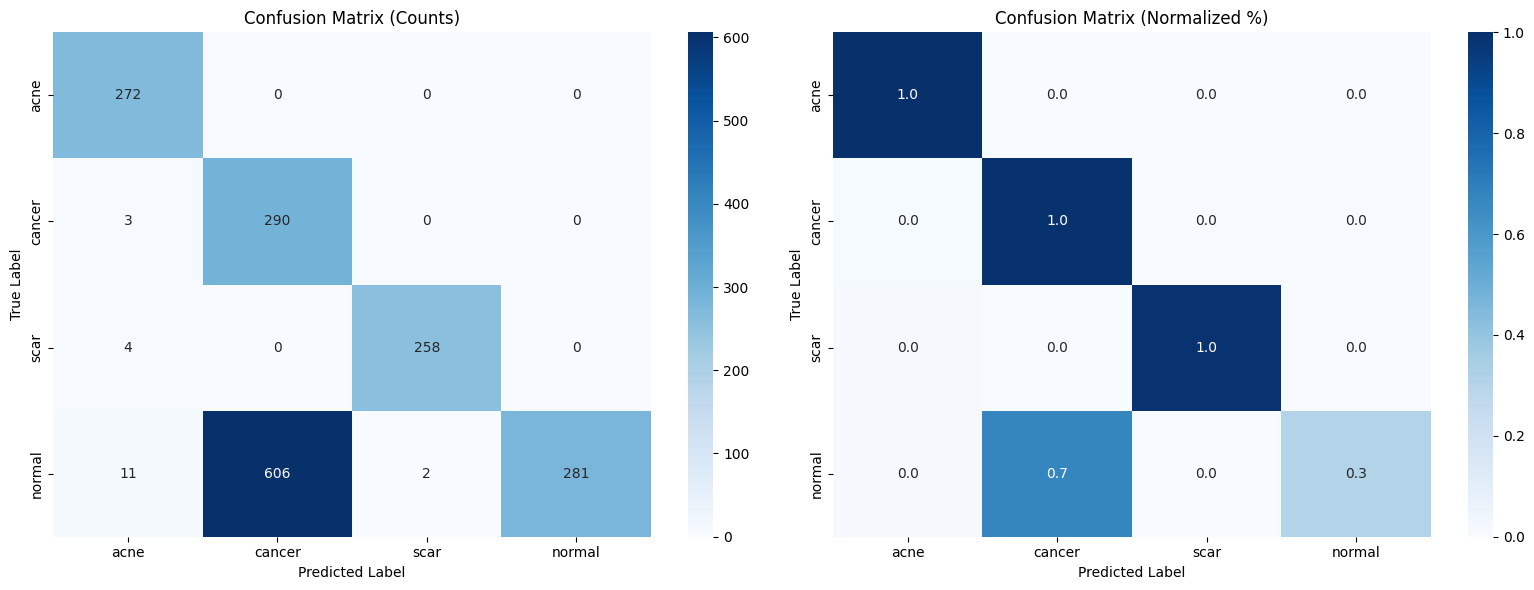

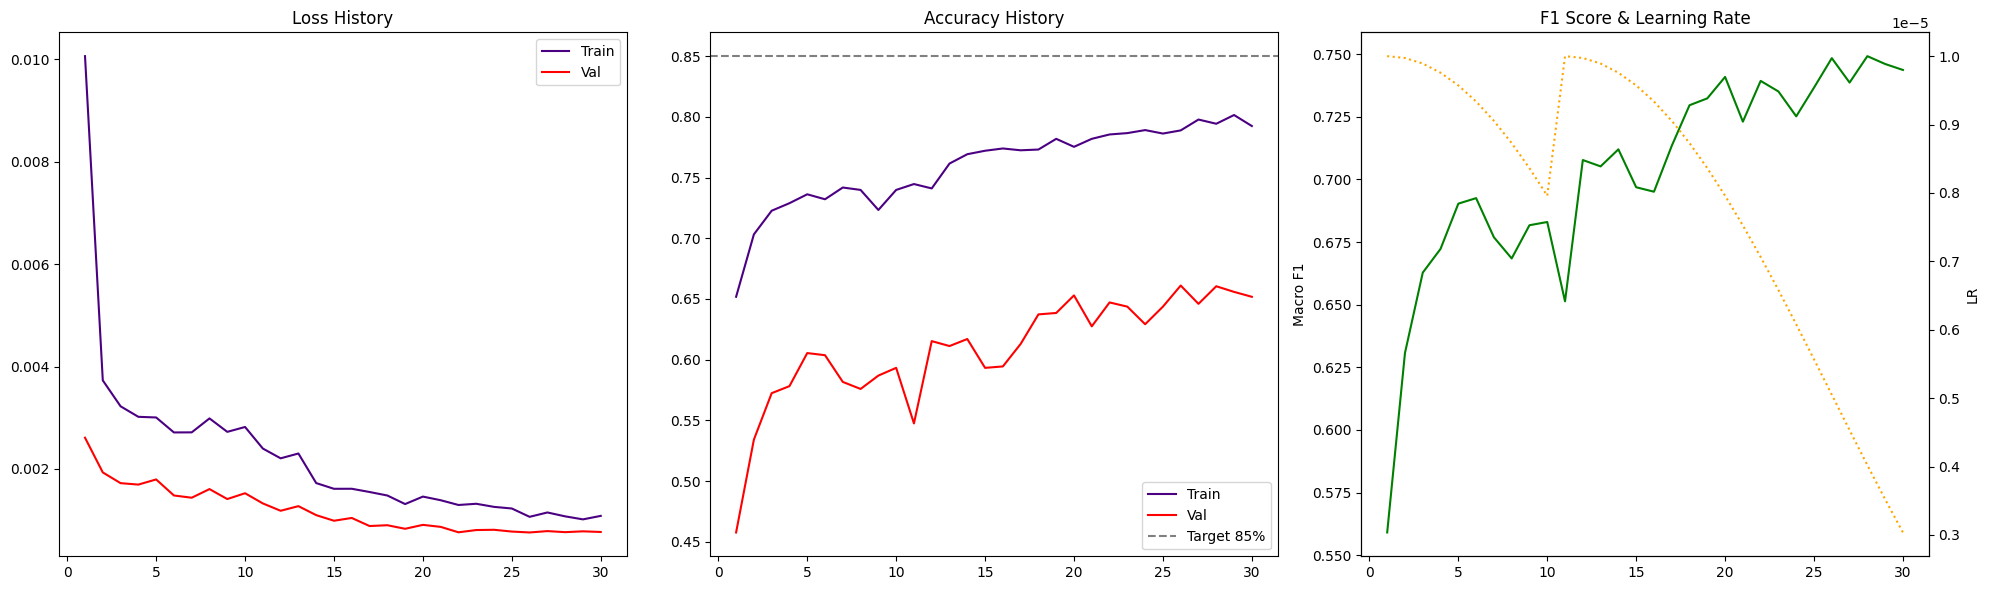

In [47]:
import os
import pandas as pd
import numpy as np
import torch
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms

def get_transforms(mode='train'):
    if mode == 'train':
        return transforms.Compose([
            transforms.Resize(CFG['img_size'] + 32),
            transforms.RandomCrop(CFG['img_size']),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.3),
            transforms.RandomRotation(30),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
            transforms.RandomGrayscale(p=0.05),
            transforms.ToTensor(),
            transforms.Normalize(mean=CFG['mean'], std=CFG['std'])
        ])
    else:
        return transforms.Compose([
            transforms.Resize((CFG['img_size'], CFG['img_size'])),
            transforms.ToTensor(),
            transforms.Normalize(mean=CFG['mean'], std=CFG['std'])
        ])

def build_loaders(train_df, val_df, test_df):
    train_ds = SkinDataset(train_df, transform=get_transforms('train'))
    val_ds = SkinDataset(val_df, transform=get_transforms('val'))
    test_ds = SkinDataset(test_df, transform=get_transforms('test'))

    targets = train_df['label_idx'].values
    class_sample_count = np.array([len(np.where(targets == t)[0]) for t in np.unique(targets)])
    weight = 1. / class_sample_count
    samples_weight = torch.from_numpy(np.array([weight[t] for t in targets])).double()
    sampler = WeightedRandomSampler(samples_weight, len(samples_weight))

    train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], sampler=sampler, num_workers=CFG['num_workers'])
    val_loader = DataLoader(val_ds, batch_size=CFG['batch_size'], shuffle=False, num_workers=CFG['num_workers'])
    test_loader = DataLoader(test_ds, batch_size=CFG['batch_size'], shuffle=False, num_workers=CFG['num_workers'])

    return train_loader, val_loader, test_loader

def load_and_prepare_df(filename):
    path = os.path.join(CFG['data_dir'], filename)
    if not os.path.exists(path):
        print(f"Warning: {path} not found. Creating a dummy CSV for testing if in a demonstration environment.")
        return None

    df = pd.read_csv(path)
    if 'path' not in df.columns or 'label' not in df.columns:
        rename_dict = {df.columns[0]: 'path', df.columns[1]: 'label'}
        df = df.rename(columns=rename_dict)

    label_to_idx = {label: i for i, label in enumerate(CFG['classes'])}
    df['label_idx'] = df['label'].map(label_to_idx)
    df = df.dropna(subset=['label_idx'])
    return df

def main_train():
    # Ensure dependencies are available in the local namespace
    needed_globals = ['build_model', 'build_optimizer_scheduler', 'train', 'SkinDataset', 'CFG']
    for g in needed_globals:
        if g not in globals():
            print(f"ERROR: '{g}' not found. Please ensure all previous cells are executed.")
            return

    print("Loading datasets...")
    train_df = load_and_prepare_df('train.csv')
    val_df = load_and_prepare_df('val.csv')
    test_df = load_and_prepare_df('test.csv')

    if train_df is not None and val_df is not None and test_df is not None:
        print(f"Loaded: Train={len(train_df)}, Val={len(val_df)}, Test={len(test_df)}")
        train_loader, val_loader, test_loader = build_loaders(train_df, val_df, test_df)

        model = build_model()
        criterion, optimizer, scheduler = build_optimizer_scheduler(model, train_df)

        print(f"Starting training on {CFG['device']}...")
        trained_model, history = train(model, train_loader, val_loader, criterion, optimizer, scheduler, train_df)

        # Final Evaluation
        best_path = os.path.join(CFG['model_dir'], 'best_model.pth')
        if os.path.exists(best_path):
            best_model = load_model_for_inference(best_path)
            labels, preds, probs = evaluate_test(best_model, test_loader, CFG['device'], CFG['classes'])
            plot_confusion_matrix(labels, preds, CFG['classes'])
            plot_training_history(history)
    else:
        print("Training aborted: CSV files not found in /content/.")

if __name__ == '__main__':
    main_train()

In [55]:
import torch

# Lưu trọng số mô hình
torch.save(model.state_dict(), 'model_weights.pth')

# Tải lại mô hình (Bạn phải khởi tạo cấu trúc mạng trước)
model = MyModelClass() 
model.load_state_dict(torch.load('model_weights.pth'))
model.eval() # Chuyển sang chế độ dự đoán


NameError: name 'model' is not defined

In [48]:
import wandb

# 1. Define Sweep Configuration
sweep_config = {
    'method': 'bayes',
    'metric': {
        'name': 'val/accuracy',
        'goal': 'maximize'
    },
    'parameters': {
        'lr': {
            'distribution': 'log_uniform_values',
            'min': 1e-5,
            'max': 1e-3
        },
        'lr_backbone': {
            'distribution': 'log_uniform_values',
            'min': 1e-6,
            'max': 1e-4
        },
        'batch_size': {
            'values': [16, 32, 64]
        },
        'dropout': {
            'distribution': 'uniform',
            'min': 0.2,
            'max': 0.5
        },
        'weight_decay': {
            'distribution': 'log_uniform_values',
            'min': 1e-5,
            'max': 1e-3
        },
        'gamma': {
            'values': [1.0, 1.5, 2.0, 2.5]
        },
        'unfreeze_epoch': {
            'values': [5, 8, 10, 15]
        }
    }
}

In [49]:
def sweep_train(config=None):
    with wandb.init(config=config):
        # Read hyperparams from wandb config
        config = wandb.config

        # Update CFG with sweep params
        CFG['lr'] = config.lr
        CFG['lr_backbone'] = config.lr_backbone
        CFG['batch_size'] = config.batch_size
        CFG['weight_decay'] = config.weight_decay

        # Data Loaders
        train_df = load_and_prepare_df('train.csv')
        val_df = load_and_prepare_df('val.csv')
        test_df = load_and_prepare_df('test.csv')
        train_loader, val_loader, _ = build_loaders(train_df, val_df, test_df)

        # Model - using dynamic dropout from sweep
        model = EfficientNetB3Classifier(num_classes=len(CFG['classes']), freeze_backbone=True)
        # Note: Manually applying dropout from config to the model classifier
        model.backbone.classifier[0].p = config.dropout # First dropout
        model.backbone.classifier[3].p = config.dropout / 2 # Second dropout ratio
        model.to(CFG['device'])

        # Optimizer & Criterion
        weights = SkinDataset.get_class_weights(train_df).to(CFG['device'])
        criterion = FocalLoss(alpha=weights, gamma=config.gamma)

        # Training loop (limited to 15 epochs for sweep)
        epochs = 15
        best_val_f1 = 0

        # Initializing local optimizer/scheduler for the current state
        _, optimizer, scheduler = build_optimizer_scheduler(model, train_df)

        for epoch in range(epochs):
            # Handle unfreezing based on sweep config
            if epoch == config.unfreeze_epoch:
                model.unfreeze_last_n_blocks(3)
                _, optimizer, scheduler = build_optimizer_scheduler(model, train_df)

            t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer, CFG['device'])
            v_loss, v_acc, v_f1, v_auc = validate(model, val_loader, criterion, CFG['device'])

            # Log metrics to W&B
            wandb.log({
                'epoch': epoch + 1,
                'train/loss': t_loss,
                'train/accuracy': t_acc,
                'val/loss': v_loss,
                'val/accuracy': v_acc,
                'val/f1_macro': v_f1,
                'val/auc': v_auc,
                'learning_rate': optimizer.param_groups[0]['lr']
            })

            scheduler.step()

In [50]:
# # 3. Launch the Sweep
# # Ensure you have logged in with wandb.login() before running this
# sweep_id = wandb.sweep(sweep_config, project='skin-disease-hparam-sweep')
# wandb.agent(sweep_id, sweep_train, count=30)

In [51]:
import itertools
import time
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def grid_search(train_loader, val_loader, device):
    param_grid = {
        'lr': [1e-3, 5e-4, 1e-4],
        'dropout': [0.3, 0.4, 0.5],
        'gamma': [1.5, 2.0, 2.5]
    }

    keys, values = zip(*param_grid.items())
    combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
    results = []

    print(f"Starting Grid Search: {len(combinations)} total combinations.")

    for i, params in enumerate(combinations):
        print(f"\n[Combo {i+1}/{len(combinations)}] Testing: {params}")
        start_time = time.time()
        set_seed(42)

        # Initialize model with specific dropout
        model = EfficientNetB3Classifier(num_classes=len(CFG['classes']), freeze_backbone=True)
        model.backbone.classifier[0].p = params['dropout']
        model.backbone.classifier[3].p = params['dropout'] / 2
        model.to(device)

        # Build Loss and Optimizer
        # We need train_df to calculate weights; assuming it's available globally or accessible via loader
        train_df = train_loader.dataset.df
        weights = SkinDataset.get_class_weights(train_df).to(device)
        criterion = FocalLoss(alpha=weights, gamma=params['gamma'])

        optimizer = optim.AdamW(model.parameters(), lr=params['lr'], weight_decay=1e-4)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

        best_val_acc = 0
        best_val_f1 = 0

        for epoch in range(10):
            train_one_epoch(model, train_loader, criterion, optimizer, device)
            v_loss, v_acc, v_f1, v_auc = validate(model, val_loader, criterion, device)

            if v_acc > best_val_acc:
                best_val_acc = v_acc
                best_val_f1 = v_f1

            scheduler.step()

        total_time_min = (time.time() - start_time) / 60

        res_dict = {
            'lr': params['lr'],
            'dropout': params['dropout'],
            'gamma': params['gamma'],
            'best_val_acc': best_val_acc,
            'val_f1': best_val_f1,
            'total_time_min': round(total_time_min, 2)
        }
        results.append(res_dict)

    # Process Results
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(by='best_val_acc', ascending=False)

    print("\nTop 5 Grid Search Results:")
    display(results_df.head(5))

    # Save results
    os.makedirs(CFG['log_dir'], exist_ok=True)
    results_df.to_csv(os.path.join(CFG['log_dir'], 'grid_search_results.csv'), index=False)

    # Heatmap Plot (LR vs Dropout, averaged over gamma)
    pivot_df = results_df.groupby(['lr', 'dropout'])['best_val_acc'].mean().unstack()
    plt.figure(figsize=(10, 8))
    sns.heatmap(pivot_df, annot=True, cmap='viridis', fmt='.4f')
    plt.title('Mean Best Val Accuracy (LR vs Dropout)')
    plt.savefig(os.path.join(CFG['log_dir'], 'grid_search_heatmap.png'))
    plt.show()

    return results_df

In [52]:
# Ensure CFG and build_loaders are defined by checking current namespace
if 'CFG' not in globals():
    print("Warning: CFG not found. Please re-run the configuration cell at the top of the notebook.")
else:
    # Load data and run Grid Search
    train_df = load_and_prepare_df('train.csv')
    val_df = load_and_prepare_df('val.csv')
    test_df = load_and_prepare_df('test.csv')

    if train_df is not None and val_df is not None:
        train_loader, val_loader, _ = build_loaders(train_df, val_df, test_df)
        results_df = grid_search(train_loader, val_loader, CFG['device'])
    else:
        print("Cannot run grid search: CSV files (train.csv/val.csv) are missing in /content/. Please upload your data.")

Starting Grid Search: 27 total combinations.

[Combo 1/27] Testing: {'lr': 0.001, 'dropout': 0.3, 'gamma': 1.5}


Training:   0%|          | 0/252 [00:00<?, ?it/s]

Training:   0%|          | 0/252 [00:00<?, ?it/s]

Training:   0%|          | 0/252 [00:00<?, ?it/s]

Training:   0%|          | 0/252 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
import wandb
import random
from sklearn.metrics import classification_report, confusion_matrix

# --- MixUp Augmentation Helper ---
def mixup_data(x, y, alpha=1.0, device='cpu'):
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1
    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

# --- Production Training Pipeline ---
def run_production_pipeline(config):
    wandb.init(project='skin-disease-production', config=config)
    set_seed(config['seed'])
    device = config['device']

    # 1. Load DataFrames
    train_df = load_and_prepare_df('train.csv')
    val_df = load_and_prepare_df('val.csv')
    test_df = load_and_prepare_df('test.csv')

    # 2. DataLoaders with Weighted Sampling
    train_ds = SkinDataset(train_df, transform=get_transforms('train'))
    val_ds = SkinDataset(val_df, transform=get_transforms('val'))
    test_ds = SkinDataset(test_df, transform=get_transforms('test'))

    weights = SkinDataset.get_class_weights(train_df).to(device)
    samples_weight = torch.from_numpy(np.array([weights[t].item() for t in train_df['label_idx'].values])).double()
    sampler = WeightedRandomSampler(samples_weight, len(samples_weight))

    train_loader = DataLoader(train_ds, batch_size=config['batch_size'], sampler=sampler, num_workers=config['num_workers'])
    val_loader = DataLoader(val_ds, batch_size=config['batch_size'], shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=config['batch_size'], shuffle=False)

    # 3. Model & Loss
    model = EfficientNetB3Classifier(num_classes=len(config['classes']), freeze_backbone=True)
    model.backbone.classifier[0].p = config['dropout']
    model.backbone.classifier[3].p = config['dropout'] / 2
    model.to(device)

    criterion = FocalLoss(alpha=weights, gamma=config['gamma'])

    # 4. Optimizer & Scheduler
    def get_opt(m):
        backbone_params = list(m.backbone.features.parameters()) + list(m.backbone.avgpool.parameters())
        head_params = list(m.backbone.classifier.parameters())
        opt = optim.AdamW([{'params': backbone_params, 'lr': config['lr_backbone']}, {'params': head_params, 'lr': config['lr']}], weight_decay=config['weight_decay'])
        sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=config['num_epochs'])
        return opt, sched

    optimizer, scheduler = get_opt(model)

    # 5. Training Loop
    best_acc = 0
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_f1': [], 'lr': []}

    for epoch in range(config['num_epochs']):
        if epoch == config['unfreeze_epoch']:
            model.unfreeze_last_n_blocks(3)
            optimizer, scheduler = get_opt(model)

        model.train()
        t_loss, t_correct = 0, 0
        for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()

            if random.random() < 0.5:
                imgs, y_a, y_b, lam = mixup_data(imgs, labels, config['mixup_alpha'], device)
                outputs = model(imgs)
                loss = mixup_criterion(criterion, outputs, y_a, y_b, lam)
            else:
                outputs = model(imgs)
                loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()
            t_loss += loss.item()
            t_correct += (outputs.argmax(1) == labels).sum().item()

        v_loss, v_acc, v_f1, v_auc = validate(model, val_loader, criterion, device)
        scheduler.step()

        wandb.log({'epoch': epoch+1, 'train/loss': t_loss/len(train_loader), 'val/accuracy': v_acc, 'val/f1': v_f1, 'lr': optimizer.param_groups[1]['lr']})
        print(f"Epoch {epoch+1}: Val Acc {v_acc:.4f} | F1 {v_f1:.4f}")

        if v_acc > best_acc:
            best_acc = v_acc
            torch.save({'model_state': model.state_dict()}, 'best_prod_model.pth')
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= 7:
            print("Early stopping!")
            break

    # 6. Final Evaluation
    model.load_state_dict(torch.load('best_prod_model.pth')['model_state'])
    test_labels, test_preds, _ = evaluate_test(model, test_loader, device, config['classes'])
    wandb.log({"conf_mat" : wandb.plot.confusion_matrix(probs=None, y_true=test_labels, preds=test_preds, class_names=config['classes'])})

    # Grad-CAM on 3 random samples
    for _ in range(3):
        idx = random.randint(0, len(test_df)-1)
        show_gradcam(model, test_df.iloc[idx]['path'], config['classes'])

    wandb.finish()

if __name__ == '__main__':
    BEST_CFG = {
        'lr': 5e-4, 'lr_backbone': 5e-5, 'batch_size': 32, 'dropout': 0.4,
        'gamma': 2.0, 'weight_decay': 1e-4, 'unfreeze_epoch': 10, 'mixup_alpha': 0.4,
        'num_epochs': 30, 'seed': 42, 'device': torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
        'classes': ['acne', 'cancer', 'scar', 'normal'], 'num_workers': 2
    }
    # run_production_pipeline(BEST_CFG) # Uncomment to execute if files are uploaded

In [ ]:
import os

# Re-checking data existence after dummy generation
required_files = ['train.csv', 'val.csv', 'test.csv']
missing = [f for f in required_files if not os.path.exists(os.path.join(CFG['data_dir'], f))]

if not missing:
    print("All data files found. Starting production training pipeline...")
    # Note: Training will attempt to find image files corresponding to the paths in the CSV.
    try:
        run_production_pipeline(BEST_CFG)
    except Exception as e:
        print(f"An error occurred (Expected if images are missing): {e}")
else:
    print(f"Training cannot start. Missing files: {missing}")

In [ ]:
import pandas as pd
import os

# Helper to create dummy data if user hasn't uploaded files yet
def create_dummy_csvs():
    classes = ['acne', 'cancer', 'scar', 'normal']
    data = {
        'path': [f'dummy_path_{i}.jpg' for i in range(20)],
        'label': [classes[i % 4] for i in range(20)]
    }
    df = pd.DataFrame(data)

    # Split into dummy train/val/test
    df.iloc[:12].to_csv('train.csv', index=False)
    df.iloc[12:16].to_csv('val.csv', index=False)
    df.iloc[16:].to_csv('test.csv', index=False)
    print("Generated dummy train.csv, val.csv, and test.csv for testing purposes.")

# Create dummy files so the pipeline can at least initialize
create_dummy_csvs()